# GATEWAY -- evaluting travelers' modal shift behavior under toll policies
1. Estimate the coefficients for logit model
2. Suggest optimal toll that could achieve optimal outcomes

# Estimate Cofficients for Logit Model Using Biogeme

In [ ]:
# activate virtual environment: source .venv/bin/activate
import numpy as np
import pandas as pd
df = pd.read_csv('processedCMS2019.csv')


In [2]:
# update CHOICE from subway: 0, car: 1, bus: 2, FHV: 3 to subway: 1, car: 2, bus: 3, FHV: 4
df['CHOICE'] = df['mode'] + 1

## Distribution of the Trips

In [3]:
display(df['trip_purpose_category'].value_counts())
display(df[['trip_purpose_category','mode']].value_counts())
prop_work = len(df[df['trip_purpose_category']=='Work'])/len(df)
print('The proportion of work trips is', prop_work)
prop_maintenance = len(df[df['trip_purpose_category']=='Maintenance'])/len(df)
print('The proportion of maintenance trips is', prop_maintenance)
prop_discretionary = len(df[df['trip_purpose_category']=='Discretionary'])/len(df)
print('The proportion of discretionary trips is', prop_discretionary)

trip_purpose_category
Maintenance      9450
Discretionary    8415
Work             8105
Name: count, dtype: int64

trip_purpose_category  mode
Maintenance            1.0     7213
Discretionary          1.0     6077
Work                   1.0     3988
                       0.0     2827
Discretionary          0.0     1261
Maintenance            0.0     1115
Work                   2.0      814
Maintenance            2.0      761
Discretionary          2.0      557
                       3.0      520
Work                   3.0      476
Maintenance            3.0      361
Name: count, dtype: int64

The proportion of work trips is 0.31209087408548325
The proportion of maintenance trips is 0.3638814016172507
The proportion of discretionary trips is 0.32402772429726606


In [4]:
print('The precentage of subway work trips is', len(df[(df['trip_purpose_category']=='Work')&(df['mode']==0)]) / len(df[df['trip_purpose_category']=='Work']))
print('The precentage of car work trips is', len(df[(df['trip_purpose_category']=='Work')&(df['mode']==1)]) / len(df[df['trip_purpose_category']=='Work']))
print('The precentage of bus work trips is', len(df[(df['trip_purpose_category']=='Work')&(df['mode']==2)]) / len(df[df['trip_purpose_category']=='Work']))
print('The precentage of FHV work trips is', len(df[(df['trip_purpose_category']=='Work')&(df['mode']==3)]) / len(df[df['trip_purpose_category']=='Work']))
print()

print('The precentage of subway maintenance trips is', len(df[(df['trip_purpose_category']=='Maintenance')&(df['mode']==0)]) / len(df[df['trip_purpose_category']=='Maintenance']))
print('The precentage of car maintenance trips is', len(df[(df['trip_purpose_category']=='Maintenance')&(df['mode']==1)]) / len(df[df['trip_purpose_category']=='Maintenance']))
print('The precentage of bus maintenance trips is', len(df[(df['trip_purpose_category']=='Maintenance')&(df['mode']==2)]) / len(df[df['trip_purpose_category']=='Maintenance']))
print('The precentage of FHV maintenance trips is', len(df[(df['trip_purpose_category']=='Maintenance')&(df['mode']==3)]) / len(df[df['trip_purpose_category']=='Maintenance']))

print()
print('The precentage of subway discretionary trips is', len(df[(df['trip_purpose_category']=='Discretionary')&(df['mode']==0)]) / len(df[df['trip_purpose_category']=='Discretionary']))
print('The precentage of car discretionary trips is', len(df[(df['trip_purpose_category']=='Discretionary')&(df['mode']==1)]) / len(df[df['trip_purpose_category']=='Discretionary']))
print('The precentage of bus discretionary trips is', len(df[(df['trip_purpose_category']=='Discretionary')&(df['mode']==2)]) / len(df[df['trip_purpose_category']=='Discretionary']))
print('The precentage of FHV discretionary trips is', len(df[(df['trip_purpose_category']=='Discretionary')&(df['mode']==3)]) / len(df[df['trip_purpose_category']=='Discretionary']))

The precentage of subway work trips is 0.3487970388648982
The precentage of car work trips is 0.492041949413942
The precentage of bus work trips is 0.10043183220234424
The precentage of FHV work trips is 0.058729179518815545

The precentage of subway maintenance trips is 0.11798941798941799
The precentage of car maintenance trips is 0.7632804232804232
The precentage of bus maintenance trips is 0.08052910052910053
The precentage of FHV maintenance trips is 0.0382010582010582

The precentage of subway discretionary trips is 0.14985145573380868
The precentage of car discretionary trips is 0.7221628045157457
The precentage of bus discretionary trips is 0.06619132501485443
The precentage of FHV discretionary trips is 0.061794414735591205


## Biogeme Estimation

In [5]:
# work
work = df[df['PURPOSE'] == 1]
# maintenance
maintenance = df[df['PURPOSE'] == 2]
# discretionary
discretionary = df[df['PURPOSE'] == 3]

import biogeme.database as db
work_database = db.Database('CMS2019', work[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
maintenance_database = db.Database('CMS2019', maintenance[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
discretionary_database = db.Database('CMS2019', discretionary[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])

/Users/helen/Documents/Python/Research/TransportationPolicy/CongestionPricing/GATEWAY/Car_Subway_Bus_FHV/.venv/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [6]:
from biogeme.expressions import Variable
# Define Biogeme variables
SUB_AV = Variable('SUB_AV')
SUB_TT = Variable('SUB_TT')
SUB_CO = Variable('SUB_CO')

CAR_AV = Variable('CAR_AV')
CAR_TT = Variable('CAR_TT')
CAR_CO = Variable('CAR_CO')

BUS_AV = Variable('BUS_AV')
BUS_TT = Variable('BUS_TT')
BUS_CO = Variable('BUS_CO')

FHV_AV = Variable('FHV_AV')
FHV_TT = Variable('FHV_TT')
FHV_CO = Variable('FHV_CO')

CHOICE = Variable('CHOICE')

from biogeme.expressions import Beta
# Parameters to be estimated
ASC_CAR = Beta('ASC_CAR', 0, None, None, 0)
ASC_BUS = Beta('ASC_BUS', 0, None, None, 0)
ASC_FHV = Beta('ASC_FHV', 0, None, None, 0)
# ASC_SUB = Beta('ASC_SUB', 0, None, None, 0)

B_TIME = Beta('B_TIME', 0, None, None, 0)

B_COST_SUB = Beta('B_COST_SUB', 0, None, None, 0)
B_COST_CAR = Beta('B_COST_CAR', 0, None, None, 0)
B_COST_BUS = Beta('B_COST_BUS', 0, None, None, 0)
B_COST_FHV = Beta('B_COST_FHV', 0, None, None, 0)

# Definition of the utility functions
# V1 = ASC_SUB + B_TIME * SUB_TT + B_COST_SUB * SUB_CO
V1 = B_TIME * SUB_TT + B_COST_SUB * SUB_CO
V2 = ASC_CAR + B_TIME * CAR_TT + B_COST_CAR * CAR_CO
V3 = ASC_BUS + B_TIME * BUS_TT + B_COST_BUS * BUS_CO
V4 = ASC_FHV + B_TIME * FHV_TT + B_COST_FHV * FHV_CO

# Associate utility functions with the numbering of alternatives.
V = {1: V1, 2: V2, 3: V3, 4: V4}

# Associate the availability conditions with the alternatives.
av = {1: SUB_AV, 2: CAR_AV, 3: BUS_AV, 4: FHV_AV}

### Work Trips

In [7]:
# from biogeme import models
# logprob = models.loglogit(V, av, CHOICE)

# import biogeme.biogeme as bio
# the_biogeme = bio.BIOGEME(work_database, logprob)
# the_biogeme.modelName = 'CMS2019LogitWork'
# # the_biogeme.generate_html = False
# the_biogeme.generate_pickle = False

# # Calculate the null log likelihood for reporting.
# the_biogeme.calculate_null_loglikelihood(av)

# # Estimate the parameters
# results = the_biogeme.estimate()

# print(results.short_summary())

# # Get the results in a pandas table
# pandas_results = results.get_estimated_parameters()
# pandas_results

In [8]:
# # work trips parameters

# beta_0_sub_work = 0 # ASC_SUB = 0

# beta_1_work = pandas_results.iat[0,1].item()  # B_TIME

# beta_2_sub_work = pandas_results.iat[1,1].item()  # B_COST_SUB

# beta_0_car_work = pandas_results.iat[2,1].item()  # ASC_CAR
# beta_2_car_work = pandas_results.iat[3,1].item()  # B_COST_CAR

# beta_0_bus_work = pandas_results.iat[4,1].item()  # ASC_BUS
# beta_2_bus_work = pandas_results.iat[5,1].item()  # B_COST_BUS

# beta_0_fhv_work = pandas_results.iat[6,1].item()  # ASC_FHV
# beta_2_fhv_work = pandas_results.iat[7,1].item()  # B_COST_FHV

In [9]:
# beta_2_sub_work

### Maintenance Trips

In [10]:
# logprob = models.loglogit(V, av, CHOICE)

# the_biogeme = bio.BIOGEME(maintenance_database, logprob)
# the_biogeme.modelName = 'CMS2019LogitMaintenance'
# # the_biogeme.generate_html = False
# the_biogeme.generate_pickle = False

# # Calculate the null log likelihood for reporting.
# the_biogeme.calculate_null_loglikelihood(av)

# # Estimate the parameters
# results = the_biogeme.estimate()

# print(results.short_summary())

# # Get the results in a pandas table
# pandas_results = results.get_estimated_parameters()
# pandas_results

In [11]:
# # maintenance trips parameters

# beta_0_sub_maintenance = 0 # ASC_SUB = 0

# beta_1_maintenance = pandas_results.iat[0,1].item()  # B_TIME

# beta_2_sub_maintenance = pandas_results.iat[1,1].item()  # B_COST_SUB

# beta_0_car_maintenance = pandas_results.iat[2,1].item()  # ASC_CAR
# beta_2_car_maintenance = pandas_results.iat[3,1].item()  # B_COST_CAR

# beta_0_bus_maintenance = pandas_results.iat[4,1].item()  # ASC_BUS
# beta_2_bus_maintenance = pandas_results.iat[5,1].item()  # B_COST_BUS

# beta_0_fhv_maintenance = pandas_results.iat[6,1].item()  # ASC_FHV
# beta_2_fhv_maintenance = pandas_results.iat[7,1].item()  # B_COST_FHV

### Discretionary Trips

In [12]:
# logprob = models.loglogit(V, av, CHOICE)

# the_biogeme = bio.BIOGEME(discretionary_database, logprob)
# the_biogeme.modelName = 'CMS2019LogitDiscretionary'
# # the_biogeme.generate_html = False
# the_biogeme.generate_pickle = False

# # Calculate the null log likelihood for reporting.
# the_biogeme.calculate_null_loglikelihood(av)

# # Estimate the parameters
# results = the_biogeme.estimate()

# print(results.short_summary())

# # Get the results in a pandas table
# pandas_results = results.get_estimated_parameters()
# pandas_results

In [13]:
# beta_0_sub_discretionary = 0
# beta_1_discretionary = pandas_results.iat[0,1].item()  # B_TIME
# beta_2_sub_discretionary = pandas_results.iat[1,1].item()  # B_COST_SUB
# beta_0_car_discretionary = pandas_results.iat[2,1].item()  # ASC_CAR
# beta_2_car_discretionary = pandas_results.iat[3,1].item()  # B_COST_CAR

# # discretionary trips parameters

# beta_0_sub_discretionary = 0 # ASC_SUB = 0

# beta_1_discretionary = pandas_results.iat[0,1].item()  # B_TIME

# beta_2_sub_discretionary = pandas_results.iat[1,1].item()  # B_COST_SUB

# beta_0_car_discretionary = pandas_results.iat[2,1].item()  # ASC_CAR
# beta_2_car_discretionary = pandas_results.iat[3,1].item()  # B_COST_CAR

# beta_0_bus_discretionary = pandas_results.iat[4,1].item()  # ASC_BUS
# beta_2_bus_discretionary = pandas_results.iat[5,1].item()  # B_COST_BUS

# beta_0_fhv_discretionary = pandas_results.iat[6,1].item()  # ASC_FHV
# beta_2_fhv_discretionary = pandas_results.iat[7,1].item()  # B_COST_FHV

In [14]:
# beta_2_sub_discretionary

In [15]:
coef = pd.read_csv('GATEWAY_coefficients.csv')
# retrieve values for each variable and define a variable under the same name
for i in range(len(coef)):
    var_name = coef.at[i, 'variable']
    var_value = coef.at[i, 'value']
    globals()[var_name] = var_value

beta_2_fhv_discretionary

np.float64(-0.0094086610706841)

## Utility and Probability of Car Travel

In [16]:
def utility(purpose, mode, toll, beta0, beta1, beta2):
    i = np.nan
    j = np.nan
    
    # CHOICE: subway: 1, car: 2, bus: 3, FHV: 4
    if mode == 'subway':
        i = 1
    elif mode == 'car':
        i = 2
    elif mode == 'bus':
        i = 3
    elif mode == 'fhv':
        i = 4
    
    if purpose == 'work':
        j = 1
    elif purpose == 'maintenance':
        j = 2
    elif purpose == 'discretionary':
        j = 3
    
    return beta0 + beta1 * df[(df['CHOICE'] == i) & (df['PURPOSE'] == j)]['durationCost'].mean() + beta2 * toll

In [17]:
def logitmodelprob(utility_input_1, utility_input_2, utility_input_3, utility_input_4):

    # return the probability of the composite traveler using the mode of utility input 1
    return np.exp(utility_input_1)/(np.exp(utility_input_1)+np.exp(utility_input_2)+np.exp(utility_input_3)+np.exp(utility_input_4))

In [18]:
toll = 0

# work trips
u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
print('The utility for work subway trips under', toll, 'dollar toll is', u_sub_work)
u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
print('The utility for work car trips under', toll, 'dollar toll is', u_car_work)
u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
print('The utility for work bus trips under', toll, 'dollar toll is', u_bus_work)
u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)
print('The utility for work fhv trips under', toll, 'dollar toll is', u_fhv_work)

p1_work = logitmodelprob(u_sub_work, u_car_work, u_bus_work, u_fhv_work)
p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)
p3_work = logitmodelprob(u_bus_work, u_sub_work, u_car_work, u_fhv_work)
p4_work = logitmodelprob(u_fhv_work, u_sub_work, u_car_work, u_bus_work)
print('The probability of travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work)
print('The probability of travelers driving to complete work trips under', toll, 'dollar toll is', p2_work)
print('The probability of travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work)
print('The probability of travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work)
print()

# maintenance trips
u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
print('The utility for maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance)
u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
print('The utility for maintenance car trips under', toll, 'dollar toll is', u_car_maintenance)
u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
print('The utility for maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance)
u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)
print('The utility for maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance)

p1_maintenance = logitmodelprob(u_sub_maintenance, u_car_maintenance, u_bus_maintenance, u_fhv_maintenance)
p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)
p3_maintenance = logitmodelprob(u_bus_maintenance, u_sub_maintenance, u_car_maintenance, u_fhv_maintenance)
p4_maintenance = logitmodelprob(u_fhv_maintenance, u_sub_maintenance, u_car_maintenance, u_bus_maintenance)
print('The probability of travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance)
print('The probability of travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance)
print('The probability of travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance)
print('The probability of travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance)

print()

# discretionary trips
u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
print('The utility for discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary)
u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
print('The utility for discretionary car trips under', toll, 'dollar toll is', u_car_discretionary)
u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
print('The utility for discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary)
u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)
print('The utility for discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary)

p1_discretionary = logitmodelprob(u_sub_discretionary, u_car_discretionary, u_bus_discretionary, u_fhv_discretionary)
p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)
p3_discretionary = logitmodelprob(u_bus_discretionary, u_sub_discretionary, u_car_discretionary, u_fhv_discretionary)
p4_discretionary = logitmodelprob(u_fhv_discretionary, u_sub_discretionary, u_car_discretionary, u_bus_discretionary)
print('The probability of travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary)
print('The probability of travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary)
print('The probability of travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary)
print('The probability of travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary)

p1 = prop_work * p1_work + prop_maintenance * p1_maintenance + prop_discretionary * p1_discretionary
p2 = prop_work * p2_work + prop_maintenance * p2_maintenance + prop_discretionary * p2_discretionary
p3 = prop_work * p3_work + prop_maintenance * p3_maintenance + prop_discretionary * p3_discretionary
p4 = prop_work * p4_work + prop_maintenance * p4_maintenance + prop_discretionary * p4_discretionary
print('The overall probability of travelers taking subway under', toll, 'dollar toll is', p1)
print('The overall probability of travelers driving under', toll, 'dollar toll is', p2)
print('The overall probability of travelers taking bus under', toll, 'dollar toll is', p3)
print('The overall probability of travelers taking fhv under', toll, 'dollar toll is', p4)

The utility for work subway trips under 0 dollar toll is 0.5814840940410853
The utility for work car trips under 0 dollar toll is 1.3782490052432
The utility for work bus trips under 0 dollar toll is 0.27378839672621763
The utility for work fhv trips under 0 dollar toll is 0.9026492466555504
The probability of travelers taking subway to complete work trips under 0 dollar toll is 0.18753897323513757
The probability of travelers driving to complete work trips under 0 dollar toll is 0.4160275950297268
The probability of travelers taking bus to complete work trips under 0 dollar toll is 0.13786721113412218
The probability of travelers taking fhv to complete work trips under 0 dollar toll is 0.2585662206010135

The utility for maintenance subway trips under 0 dollar toll is 0.6115372699611057
The utility for maintenance car trips under 0 dollar toll is 2.262937416778515
The utility for maintenance bus trips under 0 dollar toll is 0.5856940608920408
The utility for maintenance fhv trips unde

In [19]:
p2_pre = p2

In [20]:
toll = 1.5

# work trips
u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
print('The utility for work subway trips under', toll, 'dollar toll is', u_sub_work)
u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
print('The utility for work car trips under', toll, 'dollar toll is', u_car_work)
u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
print('The utility for work bus trips under', toll, 'dollar toll is', u_bus_work)
u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)
print('The utility for work fhv trips under', toll, 'dollar toll is', u_fhv_work)

p1_work = logitmodelprob(u_sub_work, u_car_work, u_bus_work, u_fhv_work)
p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)
p3_work = logitmodelprob(u_bus_work, u_sub_work, u_car_work, u_fhv_work)
p4_work = logitmodelprob(u_fhv_work, u_sub_work, u_car_work, u_bus_work)
print('The probability of travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work)
print('The probability of travelers driving to complete work trips under', toll, 'dollar toll is', p2_work)
print('The probability of travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work)
print('The probability of travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work)
print()

# maintenance trips
u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
print('The utility for maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance)
u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
print('The utility for maintenance car trips under', toll, 'dollar toll is', u_car_maintenance)
u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
print('The utility for maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance)
u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)
print('The utility for maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance)

p1_maintenance = logitmodelprob(u_sub_maintenance, u_car_maintenance, u_bus_maintenance, u_fhv_maintenance)
p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)
p3_maintenance = logitmodelprob(u_bus_maintenance, u_sub_maintenance, u_car_maintenance, u_fhv_maintenance)
p4_maintenance = logitmodelprob(u_fhv_maintenance, u_sub_maintenance, u_car_maintenance, u_bus_maintenance)
print('The probability of travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance)
print('The probability of travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance)
print('The probability of travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance)
print('The probability of travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance)

print()

# discretionary trips
u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
print('The utility for discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary)
u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
print('The utility for discretionary car trips under', toll, 'dollar toll is', u_car_discretionary)
u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
print('The utility for discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary)
u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)
print('The utility for discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary)

p1_discretionary = logitmodelprob(u_sub_discretionary, u_car_discretionary, u_bus_discretionary, u_fhv_discretionary)
p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)
p3_discretionary = logitmodelprob(u_bus_discretionary, u_sub_discretionary, u_car_discretionary, u_fhv_discretionary)
p4_discretionary = logitmodelprob(u_fhv_discretionary, u_sub_discretionary, u_car_discretionary, u_bus_discretionary)
print('The probability of travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary)
print('The probability of travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary)
print('The probability of travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary)
print('The probability of travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary)

p1 = prop_work * p1_work + prop_maintenance * p1_maintenance + prop_discretionary * p1_discretionary
p2 = prop_work * p2_work + prop_maintenance * p2_maintenance + prop_discretionary * p2_discretionary
p3 = prop_work * p3_work + prop_maintenance * p3_maintenance + prop_discretionary * p3_discretionary
p4 = prop_work * p4_work + prop_maintenance * p4_maintenance + prop_discretionary * p4_discretionary
print('The overall probability of travelers taking subway under', toll, 'dollar toll is', p1)
print('The overall probability of travelers driving under', toll, 'dollar toll is', p2)
print('The overall probability of travelers taking bus under', toll, 'dollar toll is', p3)
print('The overall probability of travelers taking fhv under', toll, 'dollar toll is', p4)

The utility for work subway trips under 1.5 dollar toll is 0.825456605419148
The utility for work car trips under 1.5 dollar toll is 1.380888530823045
The utility for work bus trips under 1.5 dollar toll is 0.5379902408351149
The utility for work fhv trips under 1.5 dollar toll is 0.8866399702733049
The probability of travelers taking subway to complete work trips under 1.5 dollar toll is 0.21949323047294572
The probability of travelers driving to complete work trips under 1.5 dollar toll is 0.38250943390776293
The probability of travelers taking bus to complete work trips under 1.5 dollar toll is 0.16465543649740547
The probability of travelers taking fhv to complete work trips under 1.5 dollar toll is 0.23334189912188594

The utility for maintenance subway trips under 1.5 dollar toll is 0.9844293434061171
The utility for maintenance car trips under 1.5 dollar toll is 2.495145914176937
The utility for maintenance bus trips under 1.5 dollar toll is 0.9077093227900073
The utility for ma

In [21]:
toll = 9

# work trips
u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
print('The utility for work subway trips under', toll, 'dollar toll is', u_sub_work)
u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
print('The utility for work car trips under', toll, 'dollar toll is', u_car_work)
u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
print('The utility for work bus trips under', toll, 'dollar toll is', u_bus_work)
u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)
print('The utility for work fhv trips under', toll, 'dollar toll is', u_fhv_work)

p1_work = logitmodelprob(u_sub_work, u_car_work, u_bus_work, u_fhv_work)
p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)
p3_work = logitmodelprob(u_bus_work, u_sub_work, u_car_work, u_fhv_work)
p4_work = logitmodelprob(u_fhv_work, u_sub_work, u_car_work, u_bus_work)
print('The probability of travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work)
print('The probability of travelers driving to complete work trips under', toll, 'dollar toll is', p2_work)
print('The probability of travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work)
print('The probability of travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work)
print()

# maintenance trips
u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
print('The utility for maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance)
u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
print('The utility for maintenance car trips under', toll, 'dollar toll is', u_car_maintenance)
u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
print('The utility for maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance)
u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)
print('The utility for maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance)

p1_maintenance = logitmodelprob(u_sub_maintenance, u_car_maintenance, u_bus_maintenance, u_fhv_maintenance)
p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)
p3_maintenance = logitmodelprob(u_bus_maintenance, u_sub_maintenance, u_car_maintenance, u_fhv_maintenance)
p4_maintenance = logitmodelprob(u_fhv_maintenance, u_sub_maintenance, u_car_maintenance, u_bus_maintenance)
print('The probability of travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance)
print('The probability of travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance)
print('The probability of travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance)
print('The probability of travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance)

print()

# discretionary trips
u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
print('The utility for discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary)
u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
print('The utility for discretionary car trips under', toll, 'dollar toll is', u_car_discretionary)
u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
print('The utility for discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary)
u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)
print('The utility for discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary)

p1_discretionary = logitmodelprob(u_sub_discretionary, u_car_discretionary, u_bus_discretionary, u_fhv_discretionary)
p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)
p3_discretionary = logitmodelprob(u_bus_discretionary, u_sub_discretionary, u_car_discretionary, u_fhv_discretionary)
p4_discretionary = logitmodelprob(u_fhv_discretionary, u_sub_discretionary, u_car_discretionary, u_bus_discretionary)
print('The probability of travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary)
print('The probability of travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary)
print('The probability of travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary)
print('The probability of travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary)

p1 = prop_work * p1_work + prop_maintenance * p1_maintenance + prop_discretionary * p1_discretionary
p2 = prop_work * p2_work + prop_maintenance * p2_maintenance + prop_discretionary * p2_discretionary
p3 = prop_work * p3_work + prop_maintenance * p3_maintenance + prop_discretionary * p3_discretionary
p4 = prop_work * p4_work + prop_maintenance * p4_maintenance + prop_discretionary * p4_discretionary
print('The overall probability of travelers taking subway under', toll, 'dollar toll is', p1)
print('The overall probability of travelers driving under', toll, 'dollar toll is', p2)
print('The overall probability of travelers taking bus under', toll, 'dollar toll is', p3)
print('The overall probability of travelers taking fhv under', toll, 'dollar toll is', p4)

The utility for work subway trips under 9 dollar toll is 2.045319162309462
The utility for work car trips under 9 dollar toll is 1.3940861587222702
The utility for work bus trips under 9 dollar toll is 1.8589994613796017
The utility for work fhv trips under 9 dollar toll is 0.8065935883620774
The probability of travelers taking subway to complete work trips under 9 dollar toll is 0.3786209501014061
The probability of travelers driving to complete work trips under 9 dollar toll is 0.19741390581398888
The probability of travelers taking bus to complete work trips under 9 dollar toll is 0.31425849258218924
The probability of travelers taking fhv to complete work trips under 9 dollar toll is 0.10970665150241576

The utility for maintenance subway trips under 9 dollar toll is 2.848889710631174
The utility for maintenance car trips under 9 dollar toll is 3.6561884011690493
The utility for maintenance bus trips under 9 dollar toll is 2.51778563227984
The utility for maintenance fhv trips unde

In [22]:
print('The change in passenger vehicle traffic volume under $9 congestion pricing is:', (0.32-0.46)*100, '%')
print('The change in demand for other travel mode other than passenger vehicle under $9 congestion pricing is:', ((0.33+0.25+0.10)-(0.13+0.11+0.30))*100, '%')

The change in passenger vehicle traffic volume under $9 congestion pricing is: -14.000000000000002 %
The change in demand for other travel mode other than passenger vehicle under $9 congestion pricing is: 14.000000000000002 %


### Modal Shift Under Tolls

In [23]:
toll_array = np.arange(0, 20, 0.01)
toll_array

# work trips
prob_subway_work_array = []
prob_car_work_array = []
prob_bus_work_array = []
prob_fhv_work_array = []
for toll in toll_array:
    u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
    u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
    u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
    u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)

    p1_work = logitmodelprob(u_sub_work, u_car_work, u_bus_work, u_fhv_work)
    p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)
    p3_work = logitmodelprob(u_bus_work, u_sub_work, u_car_work, u_fhv_work)
    p4_work = logitmodelprob(u_fhv_work, u_sub_work, u_car_work, u_bus_work)

    prob_subway_work_array.append(p1_work) 
    prob_car_work_array.append(p2_work)
    prob_bus_work_array.append(p3_work)
    prob_fhv_work_array.append(p4_work)

# maintenance trips
prob_subway_maintenance_array = []
prob_car_maintenance_array = []
prob_bus_maintenance_array = []
prob_fhv_maintenance_array = []
for toll in toll_array:
    u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
    u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
    u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
    u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)

    p1_maintenance = logitmodelprob(u_sub_maintenance, u_car_maintenance, u_bus_maintenance, u_fhv_maintenance)
    p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)
    p3_maintenance = logitmodelprob(u_bus_maintenance, u_sub_maintenance, u_car_maintenance, u_fhv_maintenance)
    p4_maintenance = logitmodelprob(u_fhv_maintenance, u_sub_maintenance, u_car_maintenance, u_bus_maintenance)

    prob_subway_maintenance_array.append(p1_maintenance) 
    prob_car_maintenance_array.append(p2_maintenance)
    prob_bus_maintenance_array.append(p3_maintenance)
    prob_fhv_maintenance_array.append(p4_maintenance)

# discretionary trips
prob_subway_discretionary_array = []
prob_car_discretionary_array = []
prob_bus_discretionary_array = []
prob_fhv_discretionary_array = []
for toll in toll_array:
    u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
    u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
    u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
    u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)

    p1_discretionary = logitmodelprob(u_sub_discretionary, u_car_discretionary, u_bus_discretionary, u_fhv_discretionary)
    p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)
    p3_discretionary = logitmodelprob(u_bus_discretionary, u_sub_discretionary, u_car_discretionary, u_fhv_discretionary)
    p4_discretionary = logitmodelprob(u_fhv_discretionary, u_sub_discretionary, u_car_discretionary, u_bus_discretionary)

    prob_subway_discretionary_array.append(p1_discretionary) 
    prob_car_discretionary_array.append(p2_discretionary)
    prob_bus_discretionary_array.append(p3_discretionary)
    prob_fhv_discretionary_array.append(p4_discretionary)

# element-wise multiplication and sum
prob_subway_array = (prop_work * np.array(prob_subway_work_array)) + (prop_maintenance * np.array(prob_subway_maintenance_array)) + (prop_discretionary * np.array(prob_subway_discretionary_array))
prob_car_array = (prop_work * np.array(prob_car_work_array)) + (prop_maintenance * np.array(prob_car_maintenance_array)) + (prop_discretionary * np.array(prob_car_discretionary_array))
prob_bus_array = (prop_work * np.array(prob_bus_work_array)) + (prop_maintenance * np.array(prob_bus_maintenance_array)) + (prop_discretionary * np.array(prob_bus_discretionary_array))
prob_fhv_array = (prop_work * np.array(prob_fhv_work_array)) + (prop_maintenance * np.array(prob_fhv_maintenance_array)) + (prop_discretionary * np.array(prob_fhv_discretionary_array))

# find where prob_car_array is closest to 0.29 (0.46-0.17)
index_29 = (np.abs(prob_car_array - 0.29)).argmin()
toll_29 = toll_array[index_29]
print('The congestion pricing charge that makes the probability of driving equal to 0.29 is', toll_29)

# find where prob_car_work_array is closest to 0.25 (0.42-0.17)
index_25_work = (np.abs(np.array(prob_car_work_array) - 0.25)).argmin()
toll_25_work = toll_array[index_25_work]
print('The congestion pricing charge that makes the probability of driving equal to 0.25 for work trips is', toll_25_work)

The congestion pricing charge that makes the probability of driving equal to 0.29 is 10.44
The congestion pricing charge that makes the probability of driving equal to 0.25 for work trips is 6.79


#### Visualization

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(rc = {'figure.figsize':(8,6.5)})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'

# matplotlib color codes can be found here: https://matplotlib.org/stable/gallery/color/named_colors.html

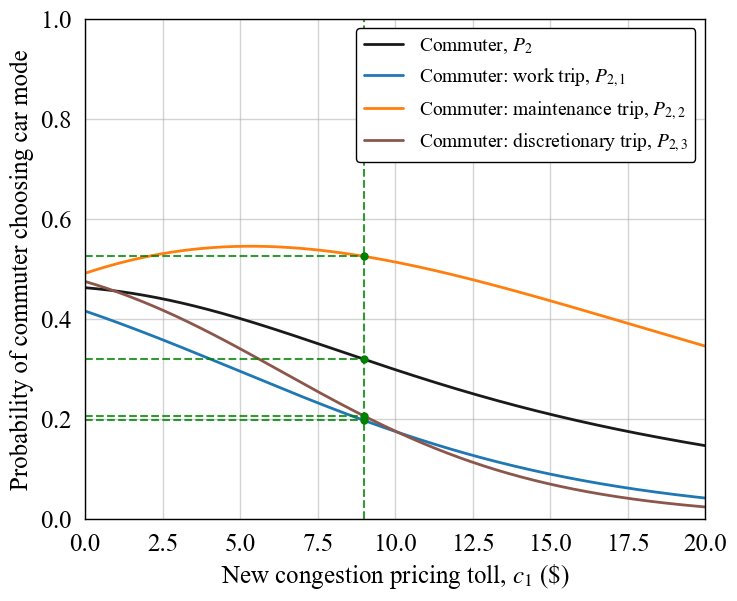

In [25]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_array, color = 'k', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

# plot probability of driving for work trips, maintenance trips, discretionary trips
plt.plot(toll_array, prob_car_work_array, color = 'tab:blue', linewidth=2)
plt.plot(toll_array, prob_car_maintenance_array, color = 'tab:orange', linewidth=2)
plt.plot(toll_array, prob_car_discretionary_array, color = 'tab:brown', linewidth=2)

leg = plt.legend(['Commuter, $P_{2}$','Commuter: work trip, $P_{2,1}$', 'Commuter: maintenance trip, $P_{2,2}$', 'Commuter: discretionary trip, $P_{2,3}$'], loc='upper right', edgecolor='black', framealpha=1, fontsize = 14)
leg.get_frame().set_facecolor('white') # Remove the background

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
# prob_car_array is np.array, no need to convert
plt.axhline(y=prob_car_array[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
# prob_car_work_array, prob_car_maintenance_array, and prob_car_discretionary_array are lists not np.array, need to convert
plt.axhline(y=np.array(prob_car_work_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5,alpha=0.8)
plt.axhline(y=np.array(prob_car_maintenance_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_discretionary_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, prob_car_array[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_work_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_maintenance_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_discretionary_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('New congestion pricing toll, $c_{1}$ (\$)')
plt.ylabel('Probability of commuter choosing car mode')
ax.set_facecolor('white') 
ax.grid(True, color='#A9A9A9', alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

plt.savefig('probCarTripPurpose.pdf', dpi=1200, bbox_inches='tight')

plt.show()

## Travel Duration Change due to Reduced Traffic at $9 Toll

In [26]:
# Volume-Delay Function: TTcar,1​=TTcar,0​(1+α(V/C​)^β), where α=0.25, β=1.5
# assuming current on-road traffic is at capacity, at $9 toll, V/C = prob_car_array[np.where(toll_array == 9)]/prob_car_array[0]
alpha = 0.25
beta = 1.5

In [27]:
avg_car_duration_at_capacity = df[df['mode']==1]['trip_duration'].mean()
average_car_duration_free_flow = avg_car_duration_at_capacity / (1 + alpha * (1)**beta)

In [28]:
updatedDuration = average_car_duration_free_flow * (1 + alpha * (prob_car_array[np.where(toll_array == 9)]/prob_car_array[0])**beta)
print('The updated travel duration for car mode under $9 congestion pricing is', updatedDuration)
print('The change in travel duration for car mode under $9 congestion pricing is', df[df['mode']==1]['trip_duration'].mean() - updatedDuration)

The updated travel duration for car mode under $9 congestion pricing is [16.25068347]
The change in travel duration for car mode under $9 congestion pricing is [1.51309127]


### Travel Duration Change under Tolls

In [29]:
updated_duration_array = average_car_duration_free_flow * (1 + alpha * (prob_car_array/prob_car_array[0])**beta)

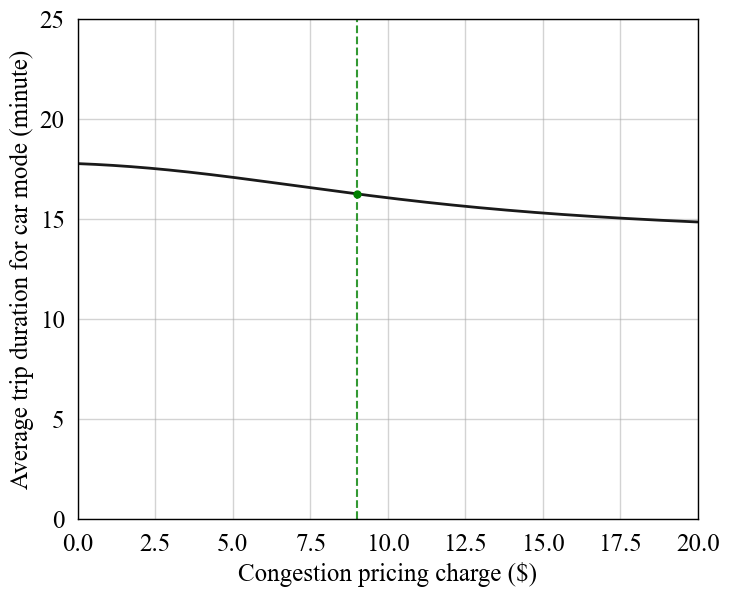

In [30]:
fig, ax = plt.subplots()
plt.plot(toll_array, updated_duration_array, color = 'k', linewidth=2)
plt.ylim(0, 25)
plt.xlim(0, 20)

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, updated_duration_array[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Average trip duration for car mode (minute)')
ax.set_facecolor('white') 
ax.grid(True, color='#A9A9A9', alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# plt.savefig('tripDuration.pdf', dpi=1200, bbox_inches='tight')

plt.show()

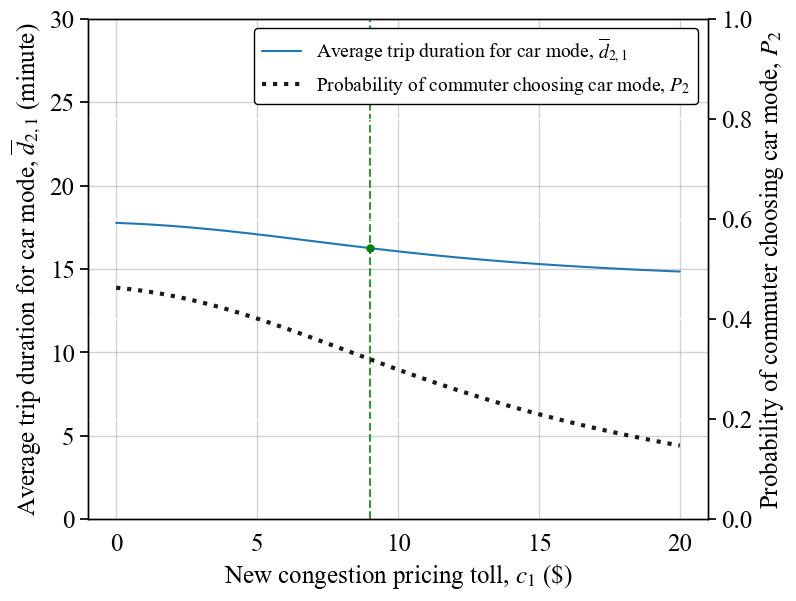

In [31]:
fig, ax1 = plt.subplots()
ax1.set_ylim(0, 30)


ax1.set_facecolor('white') 
ax1.grid(True, color='#A9A9A9', alpha=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.set_xlabel('New congestion pricing toll, $c_{1}$ (\$)')
ax1.set_ylabel('Average trip duration for car mode, $ \overline{d}_{2,1} $ (minute)')
# ax1.plot(toll_array, car_consumer_surplus, color='tab:blue')
line1, = ax1.plot(toll_array, updated_duration_array, color='tab:blue', label = 'Average trip duration for car mode, $ \overline{d}_{2,1} $')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')
# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, updated_duration_array[np.where(toll_array == 9)], marker='o', color='green', markersize=5)


ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylim(0, 1)

# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax2.set_ylabel('Probability of commuter choosing car mode, $P_{2}$')
# ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3)

line2, = ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3, label = 'Probability of commuter choosing car mode, $P_{2}$')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
leg = ax1.legend(lines, labels, loc='best', fontsize = 14, edgecolor='black', framealpha=1)
# plt.legend(frameon=False)  # Remove the frame
leg.get_frame().set_facecolor('white') # Remove the background
# Change the frame color of ax1 to black, and set the line width to 1
ax1.spines['top'].set_color('black')
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')
ax1.spines['right'].set_color('black')
ax1.spines['top'].set_linewidth(1)
ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['right'].set_linewidth(1)

# Change the frame color of ax2 to black, and set the line width to 1
ax2.spines['top'].set_color('black')
ax2.spines['bottom'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['right'].set_color('black')
ax2.spines['top'].set_linewidth(1)
ax2.spines['bottom'].set_linewidth(1)
ax2.spines['left'].set_linewidth(1)
ax2.spines['right'].set_linewidth(1)

plt.savefig('tripDuration.pdf', dpi=1200, bbox_inches='tight')

## Suggest Optimal Tolls

In [32]:
# # the number of vehicle registered in NYC is 2199824
# N = 2199824

# Revision 1 pre-congestion pricing traffic volume estimation:
# number of vehicles entering the zone is down by 12 percent since congestion pricing started and every day, 87,000 fewer vehicles enter the zone (source: https://www.governor.ny.gov/news/less-traffic-safer-streets-summer-comes-end-governor-hochul-highlights-continued-success#:~:text=Congestion%20pricing%20has%20shown%20continued,Williamsburg%20Bridge:%2023%20percent%20faster) --> daily pre-congestion pricing traffic volume = 87000/0.12 = 725000
# 93% of traffic is from passenger vehicle --> 725000*0.93 = 674250
# N = 674250

# Revision 2 pre-congestion pricing traffic volume using historical daily average baseline data from MTA:
# https://metrics.mta.info/?cbdtp/vehiclereductions
N = (533452 + 541244 + 560255 + 568143 + 580226 + 570327 + 553291 + 553231 + 570357 + 571770 + 559344 + 524270)/12
print('The number of vehicle entering CBD prior to the implementation of congestion pricing is', N)

# 93% of traffic is from passenger vehicle --> 725000*0.93 = 674250 (MTA traffic volume data in 2019)
# N = N * 0.93

# 57% of traffic is from passenger vehicle --> 725000*0.57 = 413250 (MTA vehicle entries in CBD in 2025)
N = N * 0.57
print('The estimated pre-congestion pricing daily passenger vehicle traffic volume is', N)

The number of vehicle entering CBD prior to the implementation of congestion pricing is 557159.1666666666
The estimated pre-congestion pricing daily passenger vehicle traffic volume is 317580.725


In [33]:
# def calculateConsumerSurplus(toll, p2_previous, p2_current):
#     # consumer surplus is defined in GATEWAY paper eq. (1)
#     consumerSurplus = (-toll) * p2_previous * N + 1/2 * (-toll) * (p2_current - p2_previous) * N # if N is the number of all commuters
#     return consumerSurplus

def calculateConsumerSurplus(toll, p2_previous, p2_current):
    # when N is the number of vehicles entering the zone under congestion pricing --> Q_{2,pre} = N and Q_{2,cur} = N/p2_previous * p2_current
    consumerSurplus = (-toll) * N + 1/2 * (-toll) * (N/p2_previous * p2_current - N)
    return consumerSurplus

In [34]:
# def calculateRevenue(toll, p2_current):
#     # revenue is defined in GATEWAY paper eq. (2)
#     return toll * p2_current * N # if N is the number of all commuters

def calculateRevenue(toll, p2_pre, p2_current):
    # N/p2_pre * p2_current is the number of vehicles entering the zone under congestion pricing
    return toll * N/p2_pre * p2_current # if N is the number of passenger vehicle commuters prior to congestion pricing

### Consumer Surplus Maximization

In [35]:
toll_array = np.arange(0, 20, 0.01)

# work trips
# before congestion pricing
u_sub_work_previous = utility('work', 'subway', 0, beta_0_sub_work, beta_1_work, beta_2_sub_work)
u_car_work_previous = utility('work', 'car', 0, beta_0_car_work, beta_1_work, beta_2_car_work)
u_bus_work_previous = utility('work', 'bus', 0, beta_0_bus_work, beta_1_work, beta_2_bus_work)
u_fhv_work_previous = utility('work', 'fhv', 0, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)

p2_work_previous = logitmodelprob(u_car_work_previous, u_sub_work_previous, u_bus_work_previous, u_fhv_work_previous)

# with congestion pricing
prob_car_work_array = []
car_work_consumer_surplus = []
for toll in toll_array:
    u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
    u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
    u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
    u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)

    p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)

    prob_car_work_array.append(p2_work)

    cs_work = calculateConsumerSurplus(toll, p2_work_previous, p2_work)
    car_work_consumer_surplus.append(cs_work)

# maintenance trips
# before congestion pricing
u_sub_maintenance_previous = utility('maintenance', 'subway', 0, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
u_car_maintenance_previous = utility('maintenance', 'car', 0, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
u_bus_maintenance_previous = utility('maintenance', 'bus', 0, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
u_fhv_maintenance_previous = utility('maintenance', 'fhv', 0, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)

p2_maintenance_previous = logitmodelprob(u_car_maintenance_previous, u_sub_maintenance_previous, u_bus_maintenance_previous, u_fhv_maintenance_previous)

# with congestion pricing
prob_car_maintenance_array = []
car_maintenance_consumer_surplus = []
for toll in toll_array:
    u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
    u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
    u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
    u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)

    p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)

    prob_car_maintenance_array.append(p2_maintenance)

    cs_maintenance = calculateConsumerSurplus(toll, p2_maintenance_previous, p2_maintenance)
    car_maintenance_consumer_surplus.append(cs_maintenance)

# discretionary trips
# before congestion pricing
u_sub_discretionary_previous = utility('discretionary', 'subway', 0, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
u_car_discretionary_previous = utility('discretionary', 'car', 0, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
u_bus_discretionary_previous = utility('discretionary', 'bus', 0, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
u_fhv_discretionary_previous = utility('discretionary', 'fhv', 0, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)

p2_discretionary_previous = logitmodelprob(u_car_discretionary_previous, u_sub_discretionary_previous, u_bus_discretionary_previous, u_fhv_discretionary_previous)

# with congestion pricing
prob_car_discretionary_array = []
car_discretionary_consumer_surplus = []
for toll in toll_array:
    u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
    u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
    u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
    u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)

    p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)

    prob_car_discretionary_array.append(p2_discretionary)

    cs_discretionary = calculateConsumerSurplus(toll, p2_discretionary_previous, p2_discretionary)
    car_discretionary_consumer_surplus.append(cs_discretionary)

# element-wise multiplication and sum
car_consumer_surplus = (prop_work * np.array(car_work_consumer_surplus)) + (prop_maintenance * np.array(car_maintenance_consumer_surplus)) + (prop_discretionary * np.array(car_discretionary_consumer_surplus))

Text(0, 0.5, 'Consumer surplus, $u_{1}$ (\\$)')

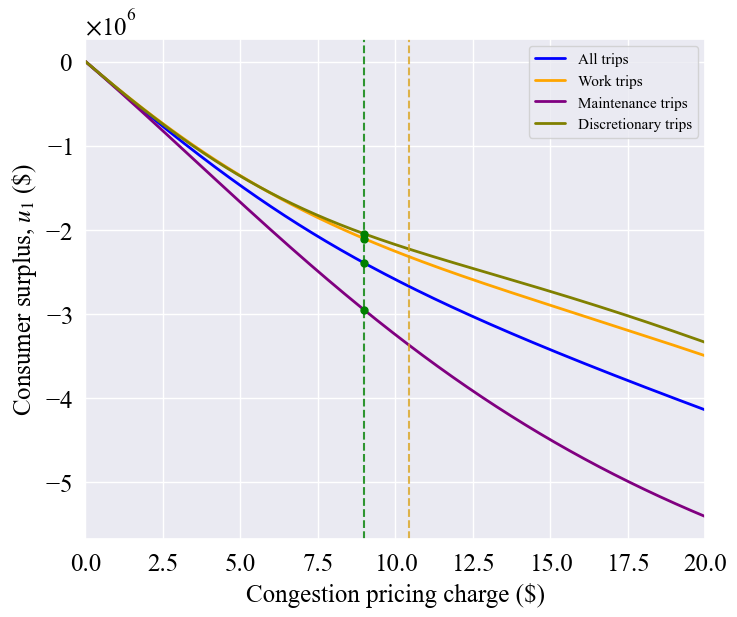

In [36]:
fig, ax = plt.subplots()
plt.plot(toll_array, car_consumer_surplus, color = 'blue', linewidth=2)
plt.xlim(0, 20)

# plot consumer surplus for work trips, maintenance trips, discretionary trips
plt.plot(toll_array, car_work_consumer_surplus, color = 'orange', linewidth=2)
plt.plot(toll_array, car_maintenance_consumer_surplus, color = 'purple', linewidth=2)
plt.plot(toll_array, car_discretionary_consumer_surplus, color = 'olive', linewidth=2)

plt.legend(['All trips','Work trips', 'Maintenance trips', 'Discretionary trips'], loc='upper right')

# plot a vertical line at x = toll_29
plt.axvline(x=toll_29, color='goldenrod', linestyle='--', alpha=0.8, label='Car traffic reduced by 17%')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, car_consumer_surplus[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(car_work_consumer_surplus)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(car_maintenance_consumer_surplus)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(car_discretionary_consumer_surplus)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Consumer surplus, $u_{1}$ (\$)')

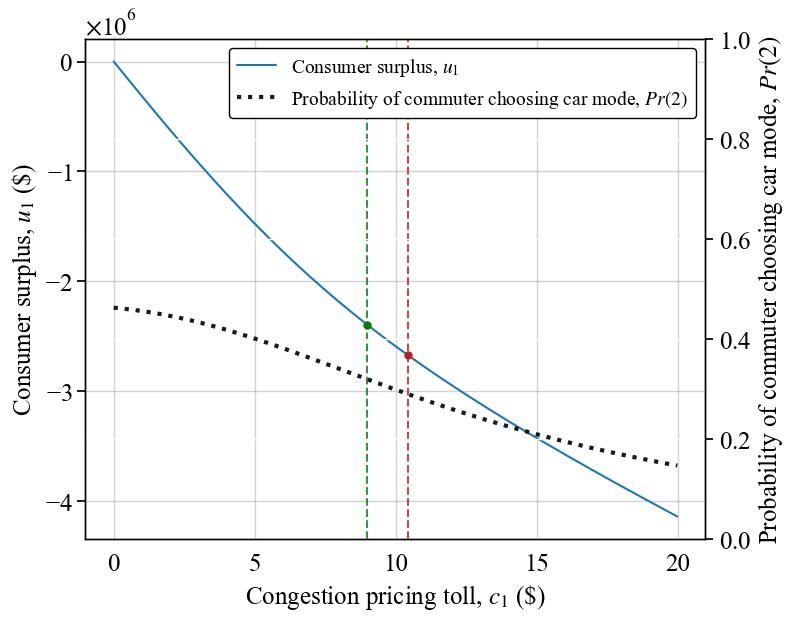

In [37]:
fig, ax1 = plt.subplots()

ax1.set_facecolor('white') 
ax1.grid(True, color='#A9A9A9', alpha=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.set_xlabel('Congestion pricing toll, $c_{1}$ (\$)')
ax1.set_ylabel('Consumer surplus, $u_{1}$ (\$)')
# ax1.plot(toll_array, car_consumer_surplus, color='tab:blue')
line1, = ax1.plot(toll_array, car_consumer_surplus, color='tab:blue', label = 'Consumer surplus, $u_{1}$')

# plot a vertical line at x = toll_29
plt.axvline(x=toll_29, color='firebrick', linestyle='--', alpha=0.8, label='Car traffic reduced by 17%')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')
# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, car_consumer_surplus[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
# plot a dot at toll = toll_29
plt.plot(toll_29, car_consumer_surplus[np.where(toll_array == toll_29)], marker='o', color='firebrick', markersize=5)


ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylim(0, 1)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax2.set_ylabel('Probability of commuter choosing car mode, $Pr(2)$')
# ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3)

line2, = ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3, label = 'Probability of commuter choosing car mode, $Pr(2)$')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
leg = ax1.legend(lines, labels, loc='best', fontsize = 14, edgecolor='black', framealpha=1)
# plt.legend(frameon=False)  # Remove the frame
leg.get_frame().set_facecolor('white') # Remove the background
# Change the frame color of ax1 to black, and set the line width to 1
ax1.spines['top'].set_color('black')
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')
ax1.spines['right'].set_color('black')
ax1.spines['top'].set_linewidth(1)
ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['right'].set_linewidth(1)

# Change the frame color of ax2 to black, and set the line width to 1
ax2.spines['top'].set_color('black')
ax2.spines['bottom'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['right'].set_color('black')
ax2.spines['top'].set_linewidth(1)
ax2.spines['bottom'].set_linewidth(1)
ax2.spines['left'].set_linewidth(1)
ax2.spines['right'].set_linewidth(1)

# plt.savefig('consumerSurplus.pdf', dpi=1200, bbox_inches='tight')

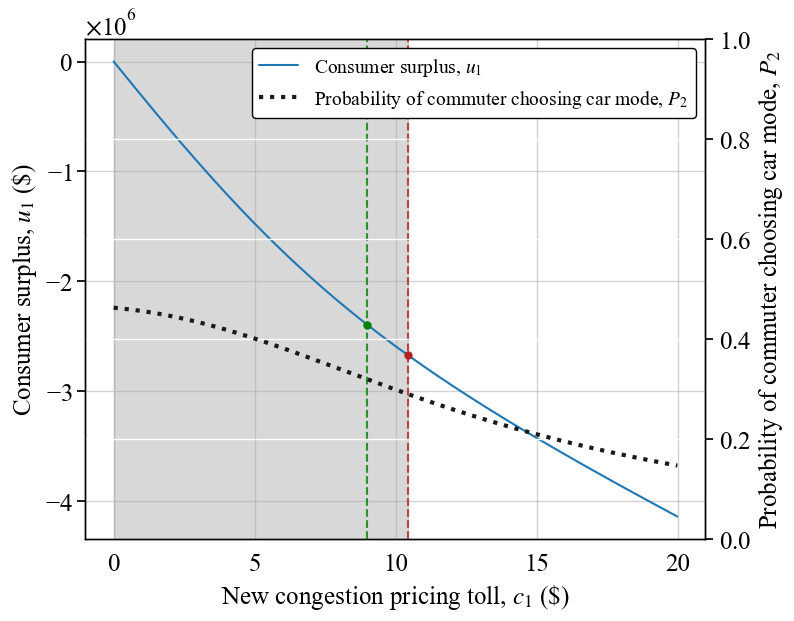

In [38]:
fig, ax1 = plt.subplots()

ax1.set_facecolor('white') 
ax1.grid(True, color='#A9A9A9', alpha=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.set_xlabel('New congestion pricing toll, $c_{1}$ (\$)')
ax1.set_ylabel('Consumer surplus, $u_{1}$ (\$)')
# ax1.plot(toll_array, car_consumer_surplus, color='tab:blue')
line1, = ax1.plot(toll_array, car_consumer_surplus, color='tab:blue', label = 'Consumer surplus, $u_{1}$')

# plot a vertical line at x = toll_29
plt.axvline(x=toll_29, color='firebrick', linestyle='--', alpha=0.8, label='Car traffic reduced by 17%')

# gray out the area under the curve from x=0 to x=toll_29
ax1.axvspan(0, toll_29, color='gray', alpha=0.3, zorder=-1) 

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')
# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, car_consumer_surplus[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
# plot a dot at toll = toll_29
plt.plot(toll_29, car_consumer_surplus[np.where(toll_array == toll_29)], marker='o', color='firebrick', markersize=5)


ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylim(0, 1)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax2.set_ylabel('Probability of commuter choosing car mode, $P_{2}$')
# ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3)

line2, = ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3, label = 'Probability of commuter choosing car mode, $P_{2}$')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
leg = ax1.legend(lines, labels, loc='best', fontsize = 14, edgecolor='black', framealpha=1)
# plt.legend(frameon=False)  # Remove the frame
leg.get_frame().set_facecolor('white') # Remove the background
# Change the frame color of ax1 to black, and set the line width to 1
ax1.spines['top'].set_color('black')
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')
ax1.spines['right'].set_color('black')
ax1.spines['top'].set_linewidth(1)
ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['right'].set_linewidth(1)

# Change the frame color of ax2 to black, and set the line width to 1
ax2.spines['top'].set_color('black')
ax2.spines['bottom'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['right'].set_color('black')
ax2.spines['top'].set_linewidth(1)
ax2.spines['bottom'].set_linewidth(1)
ax2.spines['left'].set_linewidth(1)
ax2.spines['right'].set_linewidth(1)

plt.savefig('consumerSurplus.pdf', dpi=1200, bbox_inches='tight')

In [39]:
# index_maxrev = (np.abs(revenue - revenue.max())).argmin()
# toll_maxrev = toll_array[index_maxrev]
# index_62 = (np.abs(prob_car_array - 0.62)).argmin()
# toll_62 = toll_array[index_62]

# find the index of the maximum consumer surplus from the cutoff line --> index = toll_maxcs+index_29
toll_maxcs = np.abs(car_consumer_surplus[index_29:]-car_consumer_surplus[index_29:].max()).argmin()

# toll
toll_array[toll_maxcs+index_29]

# probability of travelers driving
prob_car_array[toll_maxcs+index_29]

# change in car travel demand
prob_car_array[0]-prob_car_array[toll_maxcs+index_29]

# consumer surplus
car_consumer_surplus[toll_maxcs+index_29]
# estimated daily revenue
calculateRevenue(toll_array[toll_maxcs+index_29], prob_car_array[0], prob_car_array[toll_maxcs+index_29])

print('The congestion pricing charge that maximizes consumer surplus is $', toll_array[toll_maxcs+index_29])
print('The probability of travelers driving at $', toll_array[toll_maxcs+index_29], 'is', round(prob_car_array[toll_maxcs+index_29]*100,2), '%')
print('The change in car travel demand at $', toll_array[toll_maxcs+index_29], 'is', round((prob_car_array[0]-prob_car_array[toll_maxcs+index_29])*100,2), '%')
print('The estimated daily revenue at $', toll_array[toll_maxcs+index_29], 'is $', calculateRevenue(toll_array[toll_maxcs+index_29], prob_car_array[0], prob_car_array[toll_maxcs+index_29]))
print('The consumer surplus at $', toll_array[toll_maxcs+index_29], 'is $', car_consumer_surplus[toll_maxcs+index_29])

updatedDuration = average_car_duration_free_flow * (1 + alpha * (prob_car_array[np.where(toll_array == toll_array[toll_maxcs+index_29])]/prob_car_array[0])**beta)
print('The updated travel duration for car mode at $', toll_array[toll_maxcs+index_29], 'is', updatedDuration)
print('The change in travel duration for car mode at $', toll_array[toll_maxcs+index_29], 'is', avg_car_duration_at_capacity - updatedDuration)

The congestion pricing charge that maximizes consumer surplus is $ 10.44
The probability of travelers driving at $ 10.44 is 29.01 %
The change in car travel demand at $ 10.44 is 17.26 %
The estimated daily revenue at $ 10.44 is $ 2078824.2007241533
The consumer surplus at $ 10.44 is $ -2674070.5440380354
The updated travel duration for car mode at $ 10.44 is [15.97486288]
The change in travel duration for car mode at $ 10.44 is [1.78891186]


### Revenue Maximization

In [40]:
toll_array = np.arange(0, 20, 0.01)

# work trips
revenue_work = []
for toll in toll_array:
    u_sub_work = utility('work', 'subway', toll, beta_0_sub_work, beta_1_work, beta_2_sub_work)
    u_car_work = utility('work', 'car', toll, beta_0_car_work, beta_1_work, beta_2_car_work)
    u_bus_work = utility('work', 'bus', toll, beta_0_bus_work, beta_1_work, beta_2_bus_work)
    u_fhv_work = utility('work', 'fhv', toll, beta_0_fhv_work, beta_1_work, beta_2_fhv_work)

    p2_work = logitmodelprob(u_car_work, u_sub_work, u_bus_work, u_fhv_work)
    # save the probability of driving for work trips when the toll is 0 as p2_work_previous to calculate revenue
    if toll == 0:
        p2_work_previous = p2_work
    rev_work = calculateRevenue(toll, p2_work_previous, p2_work)
    revenue_work.append(rev_work)

# maintenance trips
revenue_maintenance = []
for toll in toll_array:
    u_sub_maintenance = utility('maintenance', 'subway', toll, beta_0_sub_maintenance, beta_1_maintenance, beta_2_sub_maintenance)
    u_car_maintenance = utility('maintenance', 'car', toll, beta_0_car_maintenance, beta_1_maintenance, beta_2_car_maintenance)
    u_bus_maintenance = utility('maintenance', 'bus', toll, beta_0_bus_maintenance, beta_1_maintenance, beta_2_bus_maintenance)
    u_fhv_maintenance = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance, beta_1_maintenance, beta_2_fhv_maintenance)

    p2_maintenance = logitmodelprob(u_car_maintenance, u_sub_maintenance, u_bus_maintenance, u_fhv_maintenance)

    if toll == 0:
        p2_maintenance_previous = p2_maintenance
    rev_maintenance = calculateRevenue(toll, p2_maintenance_previous, p2_maintenance)
    revenue_maintenance.append(rev_maintenance)

# discretionary trips
revenue_discretionary = []
for toll in toll_array:
    u_sub_discretionary = utility('discretionary', 'subway', toll, beta_0_sub_discretionary, beta_1_discretionary, beta_2_sub_discretionary)
    u_car_discretionary = utility('discretionary', 'car', toll, beta_0_car_discretionary, beta_1_discretionary, beta_2_car_discretionary)
    u_bus_discretionary = utility('discretionary', 'bus', toll, beta_0_bus_discretionary, beta_1_discretionary, beta_2_bus_discretionary)
    u_fhv_discretionary = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary, beta_1_discretionary, beta_2_fhv_discretionary)

    p2_discretionary = logitmodelprob(u_car_discretionary, u_sub_discretionary, u_bus_discretionary, u_fhv_discretionary)
    
    if toll == 0:
        p2_discretionary_previous = p2_discretionary
    rev_discretionary = calculateRevenue(toll, p2_discretionary_previous, p2_discretionary)
    revenue_discretionary.append(rev_discretionary)

# element-wise multiplication and sum
revenue = (prop_work * np.array(revenue_work)) + (prop_maintenance * np.array(revenue_maintenance)) + (prop_discretionary * np.array(revenue_discretionary))

Text(0, 0.5, 'Revenue, $u_{1}$ (\\$)')

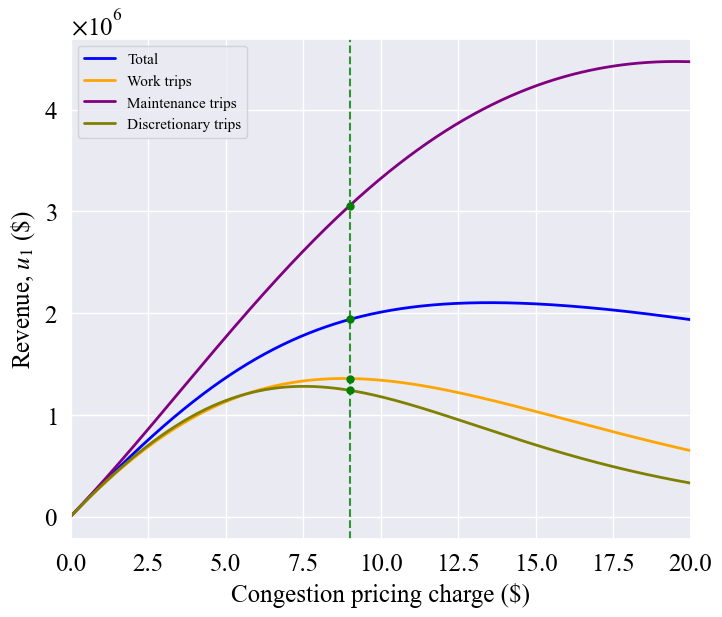

In [41]:
fig, ax = plt.subplots()
plt.plot(toll_array, revenue, color = 'blue', linewidth=2)
plt.xlim(0, 20)

# plot revenue for work trips, maintenance trips, discretionary trips
plt.plot(toll_array, revenue_work, color = 'orange', linewidth=2)
plt.plot(toll_array, revenue_maintenance, color = 'purple', linewidth=2)
plt.plot(toll_array, revenue_discretionary, color = 'olive', linewidth=2)

plt.legend(['Total','Work trips', 'Maintenance trips', 'Discretionary trips'], loc='best')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, revenue[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(revenue_work)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(revenue_maintenance)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(revenue_discretionary)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Revenue, $u_{1}$ (\$)')

In [42]:
revenue.max()

# find where revenue is maximized
index_maxrev = (np.abs(revenue - revenue.max())).argmin()
toll_maxrev = toll_array[index_maxrev]
print('The congestion pricing charge that maximizes revenue is $', toll_maxrev)
print('The probability of travelers driving at $', toll_array[index_maxrev], 'is', round(prob_car_array[index_maxrev]*100,2), '%')
print('The change in car travel demand at $', toll_array[index_maxrev], 'is', round((prob_car_array[0]-prob_car_array[index_maxrev])*100,2), '%')
print('The estimated daily revenue at $', toll_maxrev, 'is $', revenue.max())

updatedDuration = average_car_duration_free_flow * (1 + alpha * (prob_car_array[np.where(toll_array == toll_maxrev)]/prob_car_array[0])**beta)
print('The updated travel duration for car mode at $', toll_maxrev, 'is', updatedDuration)
print('The change in travel duration for car mode at $', toll_maxrev, 'is', avg_car_duration_at_capacity - updatedDuration)

The congestion pricing charge that maximizes revenue is $ 13.52
The probability of travelers driving at $ 13.52 is 23.33 %
The change in car travel demand at $ 13.52 is 22.93 %
The estimated daily revenue at $ 13.52 is $ 2102043.2411909346
The updated travel duration for car mode at $ 13.52 is [15.48316863]
The change in travel duration for car mode at $ 13.52 is [2.28060612]


In [43]:
# at $3 congestion pricing charge
index_3 = (np.abs(toll_array - 3)).argmin()
# print('The estimated daily revenue at $3 congestion pricing charge is $', revenue[index_3])
print('The probability of travelers driving at $', toll_array[index_3], 'is', round(prob_car_array[index_3]*100,2), '%')
print('The change in car travel demand at $', toll_array[index_3], 'is', round((prob_car_array[0]-prob_car_array[index_3])*100,2), '%')
print('The estimated daily revenue at $3 congestion pricing charge is $', revenue[index_3])

The probability of travelers driving at $ 3.0 is 43.37 %
The change in car travel demand at $ 3.0 is 2.89 %
The estimated daily revenue at $3 congestion pricing charge is $ 887518.5427400351


In [44]:
# at $9 congestion pricing charge
index_9 = (np.abs(toll_array - 9)).argmin()
print('The probability of travelers driving at $', toll_array[index_9], 'is', round(prob_car_array[index_9]*100,2), '%')
# print('The change in car travel demand at $', toll_array[index_9], 'is', round((prob_car_array[0]-prob_car_array[index_9])*100,2), '%')
print('The change in car travel demand at $', toll_array[index_9], 'is', round((prob_car_array[0]-prob_car_array[index_9])*100,2), '%')
print('The estimated daily revenue at $9 congestion pricing charge is $', revenue[index_9])

The probability of travelers driving at $ 9.0 is 31.96 %
The change in car travel demand at $ 9.0 is 14.31 %
The estimated daily revenue at $9 congestion pricing charge is $ 1936769.854521258


In [45]:
# at $12 congestion pricing charge (2028)
index_12 = (np.abs(toll_array - 12)).argmin()
print('The probability of travelers driving at $', toll_array[index_12], 'is', round(prob_car_array[index_12]*100,2), '%')
print('The change in car travel demand at $', toll_array[index_12], 'is', round((prob_car_array[0]-prob_car_array[index_12])*100,2), '%')
print('The estimated daily revenue at $12 congestion pricing charge is $', revenue[index_12])

updatedDuration = average_car_duration_free_flow * (1 + alpha * (prob_car_array[index_12]/prob_car_array[0])**beta)
print('The updated travel duration for car mode at $', toll_array[index_12], 'is', updatedDuration)
print('The change in travel duration for car mode at $', toll_array[index_12]
, 'is', avg_car_duration_at_capacity - updatedDuration)

The probability of travelers driving at $ 12.0 is 26.0 %
The change in car travel demand at $ 12.0 is 20.26 %
The estimated daily revenue at $12 congestion pricing charge is $ 2086910.4275136483
The updated travel duration for car mode at $ 12.0 is 15.708138748585602
The change in travel duration for car mode at $ 12.0 is 2.0556359938614417


In [46]:
# at $15 congestion pricing charge (2031)
index_15 = (np.abs(toll_array - 15)).argmin()
print('The probability of travelers driving at $', toll_array[index_15], 'is', round(prob_car_array[index_15]*100,2), '%')
print('The change in car travel demand at $', toll_array[index_15], 'is', round((prob_car_array[0]-prob_car_array[index_15])*100,2), '%')
print('The estimated daily revenue at $15 congestion pricing charge is $', revenue[index_15])

updatedDuration = average_car_duration_free_flow * (1 + alpha * (prob_car_array[index_15]/prob_car_array[0])**beta)
print('The updated travel duration for car mode at $', toll_array[index_15], 'is', updatedDuration)
print('The change in travel duration for car mode at $', toll_array[index_15]
, 'is', avg_car_duration_at_capacity - updatedDuration)

The probability of travelers driving at $ 15.0 is 20.98 %
The change in car travel demand at $ 15.0 is 25.28 %
The estimated daily revenue at $15 congestion pricing charge is $ 2090355.004155266
The updated travel duration for car mode at $ 15.0 is 15.295900707015743
The change in travel duration for car mode at $ 15.0 is 2.4678740354313007


In [47]:
# at $1.5 congestion pricing charge
index__15 = (np.abs(toll_array - 1.5)).argmin()
print('The probability of travelers using FHV at $', toll_array[index__15], 'is', round(prob_fhv_array[index__15]*100,2), '%')
print('The reduction in FHV travel demand at $', toll_array[index__15], 'is', round((prob_fhv_array[0]-prob_fhv_array[index__15])*100,2), '%')
print('The estimated daily revenue at $1.5 congestion pricing charge is $', 6903042 * (prob_fhv_array[0]- prob_fhv_array[index__15]) * 1.5) # 6903042 is the pre-congestion pricing daily FHV trip volume entering the zone (source: MTA Central Business District Taxi and For-Hire Vehicle Trips: Beginning May 2019 (Accessed: 2/11/26))

The probability of travelers using FHV at $ 1.5 is 25.94 %
The reduction in FHV travel demand at $ 1.5 is 4.06 %
The estimated daily revenue at $1.5 congestion pricing charge is $ 420025.71541681245


In [48]:
# at $0.75 congestion pricing charge
index_0__75 = (np.abs(toll_array - 0.75)).argmin()
print('The probability of travelers using taxi at $', toll_array[index_0__75], 'is', round(prob_fhv_array[index_0__75]*100,2), '%')
print('The reduction in taxi travel demand at $', toll_array[index_0__75], 'is', round((prob_fhv_array[0]-prob_fhv_array[index_0__75])*100,2), '%')
print('The estimated daily revenue at $0.75 congestion pricing charge is $', 2503442 * (prob_fhv_array[0]- prob_fhv_array[index_0__75]) * 0.75) # 2503442 is the pre-congestion pricing daily taxi trip volume entering the zone (source: MTA Central Business District Taxi and For-Hire Vehicle Trips: Beginning May 2019 (Accessed: 2/11/26))

The probability of travelers using taxi at $ 0.75 is 27.96 %
The reduction in taxi travel demand at $ 0.75 is 2.04 %
The estimated daily revenue at $0.75 congestion pricing charge is $ 38331.42568714988


In [49]:
print('The reduction in FHV (taxi and HVFHV) travel demand is', round(((prob_fhv_array[0]-prob_fhv_array[index_0__75])*0.26+(prob_fhv_array[0]-prob_fhv_array[index__15])*0.73)*100,2), '%')

The reduction in FHV (taxi and HVFHV) travel demand is 3.49 %


In [50]:
# actual traffic reduction observed from MTA data (https://metrics.mta.info/?cbdtp/vehiclereductions)
(-8 + -12 + -13 + -12 + -10 + -14 + -10 + -14 + -10 + -10 + -11 + -15)/12

-11.583333333333334

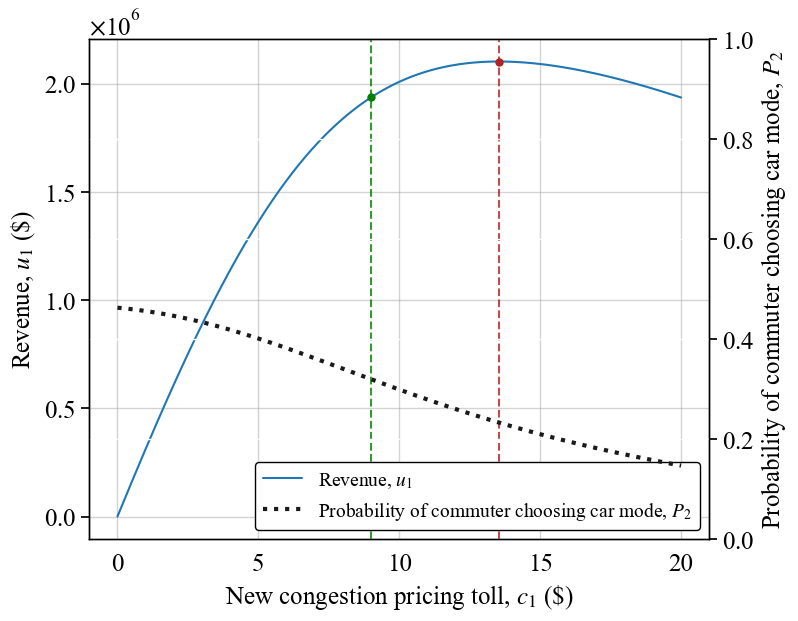

In [51]:
fig, ax1 = plt.subplots()

ax1.set_facecolor('white') 
ax1.grid(True, color='#A9A9A9', alpha=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.set_xlabel('New congestion pricing toll, $c_{1}$ (\$)')
ax1.set_ylabel('Revenue, $u_{1}$ (\$)')
# ax1.plot(toll_array, revenue, color='tab:blue')
line1, = ax1.plot(toll_array, revenue, color='tab:blue', label = 'Revenue, $u_{1}$')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')
# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, revenue[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

# plot a vertical line at x = toll_maxrev
plt.axvline(x=toll_maxrev, color='firebrick', linestyle='--', alpha=0.8, label='Revenue maximized')
# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(toll_maxrev, revenue[np.where(toll_array == toll_maxrev)], marker='o', color='firebrick', markersize=5)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylim(0, 1)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax2.set_ylabel('Probability of commuter choosing car mode, $P_{2}$')
# ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3)
line2, = ax2.plot(toll_array, prob_car_array, ls = 'dotted', color = 'k',linewidth = 3, label = 'Probability of commuter choosing car mode, $P_{2}$')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
leg = ax1.legend(lines, labels, loc='best', fontsize = 14, edgecolor='black', framealpha=1)
leg.get_frame().set_facecolor('white') # Remove the background
ax.set_axisbelow(True)
# Change the frame color of ax1 to black, and set the line width to 1
ax1.spines['top'].set_color('black')
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')
ax1.spines['right'].set_color('black')
ax1.spines['top'].set_linewidth(1)
ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['right'].set_linewidth(1)

# Change the frame color of ax2 to black, and set the line width to 1
ax2.spines['top'].set_color('black')
ax2.spines['bottom'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['right'].set_color('black')
ax2.spines['top'].set_linewidth(1)
ax2.spines['bottom'].set_linewidth(1)
ax2.spines['left'].set_linewidth(1)
ax2.spines['right'].set_linewidth(1)

plt.savefig('revenue.pdf', dpi=1200, bbox_inches='tight')

## Income

In [52]:
prop_work_high_income = len(df[(df['trip_purpose_category']=='Work')&(df['highIncome']==1)])/len(df)
print('The proportion of high-income travelers work trips is', prop_work_high_income)
prop_work_low_income = len(df[(df['trip_purpose_category']=='Work')&(df['highIncome']==0)])/len(df)
print('The proportion of low-income travelers work trips is', prop_work_low_income)

prop_maintenance_high_income = len(df[(df['trip_purpose_category']=='Maintenance')&(df['highIncome']==1)])/len(df)
print('The proportion of high-income travelers maintenance trips is', prop_maintenance_high_income)
prop_maintenance_low_income = len(df[(df['trip_purpose_category']=='Maintenance')&(df['highIncome']==0)])/len(df)
print('The proportion of low-income travelers maintenance trips is', prop_maintenance_low_income)

prop_discretionary_high_income = len(df[(df['trip_purpose_category']=='Discretionary')&(df['highIncome']==1)])/len(df)
print('The proportion of high-income travelers discretionary trips is', prop_discretionary_high_income)
prop_discretionary_low_income = len(df[(df['trip_purpose_category']=='Discretionary')&(df['highIncome']==0)])/len(df)
print('The proportion of low-income travelers discretionary trips is', prop_discretionary_low_income)

# work
work_high_income = df[(df['PURPOSE'] == 1)&(df['highIncome']==1)]
work_low_income = df[(df['PURPOSE'] == 1)&(df['highIncome']==0)]

# maintenance
maintenance_high_income = df[(df['PURPOSE'] == 2)&(df['highIncome']==1)]
maintenance_low_income = df[(df['PURPOSE'] == 2)&(df['highIncome']==0)]

# discretionary
discretionary_high_income = df[(df['PURPOSE'] == 3)&(df['highIncome']==1)]
discretionary_low_income = df[(df['PURPOSE'] == 3)&(df['highIncome']==0)]

work_high_income_database = db.Database('CMS2019', work_high_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
work_low_income_database = db.Database('CMS2019', work_low_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])

maintenance_high_income_database = db.Database('CMS2019', maintenance_high_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
maintenance_low_income_database = db.Database('CMS2019', maintenance_low_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])

discretionary_high_income_database = db.Database('CMS2019', discretionary_high_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
discretionary_low_income_database = db.Database('CMS2019', discretionary_low_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])

The proportion of high-income travelers work trips is 0.17266076241817482
The proportion of low-income travelers work trips is 0.13943011166730843
The proportion of high-income travelers maintenance trips is 0.1907200616095495
The proportion of low-income travelers maintenance trips is 0.1731613400077012
The proportion of high-income travelers discretionary trips is 0.19060454370427415
The proportion of low-income travelers discretionary trips is 0.1334231805929919


In [53]:
prop_work_high_income+prop_maintenance_high_income+prop_discretionary_high_income

0.5539853677319985

In [54]:
len(df[df['highIncome']==1])/len(df)

0.5539853677319985

In [55]:
len(df[df['highIncome']==0])

11583

In [56]:
len(df[df['highIncome']==1])

14387

In [57]:
# from biogeme import models
# logprob = models.loglogit(V, av, CHOICE)

# import biogeme.biogeme as bio
# the_biogeme = bio.BIOGEME(work_database, logprob)
# the_biogeme.modelName = 'CMS2019LogitWork'
# # the_biogeme.generate_html = False
# the_biogeme.generate_pickle = False

# # Calculate the null log likelihood for reporting.
# the_biogeme.calculate_null_loglikelihood(av)

# # Estimate the parameters
# results = the_biogeme.estimate()

# print(results.short_summary())

# # Get the results in a pandas table
# pandas_results = results.get_estimated_parameters()
# pandas_results

### High Income

In [58]:
from biogeme import models
import biogeme.biogeme as bio
# work trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(work_high_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitWorkHighIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting.
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# high-income work trips parameters

beta_0_sub_work_high_income = 0 # ASC_SUB = 0

beta_1_work_high_income = pandas_results.iat[0,1].item()  # B_TIME

beta_2_sub_work_high_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_work_high_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_work_high_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_work_high_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_work_high_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_work_high_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_work_high_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/Users/helen/Documents/Python/Research/TransportationPolicy/CongestionPricing/GATEWAY/Car_Subway_Bus_FHV/.venv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/2888030902.py:7: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitWorkHighIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/2888030902.py:9: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitWorkHighIncome
Nbr of parameters:		8
Sample size:			4484
Excluded data:			0
Null log likelihood:		-1134.627
Final log likelihood:		-1064.288
Likelihood ratio test (null):		140.6768
Rho square (null):			0.062
Rho bar square (null):			0.0549
Akaike Information Criterion:	2144.577
Bayesian Information Criterion:	2195.843



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/2888030902.py:20: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.006948,0.002108,3.295614,9.820679e-04
1,B_COST_SUB,0.139286,0.024424,5.702775,1.178725e-08
2,ASC_CAR,0.905546,0.209951,4.313134,1.609563e-05
3,B_COST_CAR,-0.007300,0.010937,-0.667421,5.045033e-01
4,ASC_BUS,-0.649589,0.225447,-2.881335,3.959946e-03
5,B_COST_BUS,0.260297,0.052291,4.977863,6.429022e-07
6,ASC_FHV,-0.133570,0.200449,-0.666353,5.051852e-01
7,B_COST_FHV,0.010063,0.006246,1.610984,1.071832e-01


In [59]:
# maintenance trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(maintenance_high_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitMaintenanceHighIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# high-income maintenance trips parameters

beta_0_sub_maintenance_high_income = 0 # ASC_SUB = 0

beta_1_maintenance_high_income = pandas_results.iat[0,1].item()  # B_TIME

beta_2_sub_maintenance_high_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_maintenance_high_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_maintenance_high_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_maintenance_high_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_maintenance_high_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_maintenance_high_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_maintenance_high_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3833179592.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitMaintenanceHighIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3833179592.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitMaintenanceHighIncome
Nbr of parameters:		8
Sample size:			4953
Excluded data:			0
Null log likelihood:		-932.7989
Final log likelihood:		-745.3217
Likelihood ratio test (null):		374.9545
Rho square (null):			0.201
Rho bar square (null):			0.192
Akaike Information Criterion:	1506.643
Bayesian Information Criterion:	1558.705



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3833179592.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.006116,0.003058,1.999702,4.553242e-02
1,B_COST_SUB,0.340586,0.054873,6.206774,5.408345e-10
2,ASC_CAR,2.406339,0.290082,8.295374,0.000000e+00
3,B_COST_CAR,0.009867,0.042208,0.233770,8.151638e-01
4,ASC_BUS,0.663316,0.282962,2.344183,1.906882e-02
5,B_COST_BUS,0.131741,0.045172,2.916450,3.540390e-03
6,ASC_FHV,1.223896,0.312077,3.921778,8.789793e-05
7,B_COST_FHV,-0.000072,0.012290,-0.005865,9.953201e-01


In [60]:
# discretionary trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(discretionary_high_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitDiscretionaryHighIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# high-income discretionary trips parameters

beta_0_sub_discretionary_high_income = 0 # ASC_SUB = 0

beta_1_discretionary_high_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_discretionary_high_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_discretionary_high_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_discretionary_high_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_discretionary_high_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_discretionary_high_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_discretionary_high_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_discretionary_high_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3618987756.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitDiscretionaryHighIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3618987756.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitDiscretionaryHighIncome
Nbr of parameters:		8
Sample size:			4950
Excluded data:			0
Null log likelihood:		-1316.317
Final log likelihood:		-1170.674
Likelihood ratio test (null):		291.2846
Rho square (null):			0.111
Rho bar square (null):			0.105
Akaike Information Criterion:	2357.349
Bayesian Information Criterion:	2409.406



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3618987756.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.007849,0.002170,3.616754,2.983204e-04
1,B_COST_SUB,0.217772,0.042863,5.080675,3.760956e-07
2,ASC_CAR,1.662324,0.217198,7.653493,1.953993e-14
3,B_COST_CAR,-0.011519,0.011874,-0.970093,3.320000e-01
4,ASC_BUS,-0.453956,0.330250,-1.374580,1.692615e-01
5,B_COST_BUS,0.267014,0.080885,3.301158,9.628657e-04
6,ASC_FHV,0.674520,0.221538,3.044715,2.329012e-03
7,B_COST_FHV,0.001340,0.006282,0.213396,8.310177e-01


### Low Income

In [61]:
# work trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(work_low_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitWorkLowIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting.
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# low-income work trips parameters

beta_0_sub_work_low_income = 0 # ASC_SUB = 0

beta_1_work_low_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_work_low_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_work_low_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_work_low_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_work_low_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_work_low_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_work_low_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_work_low_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/378379673.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitWorkLowIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/378379673.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitWorkLowIncome
Nbr of parameters:		8
Sample size:			3621
Excluded data:			0
Null log likelihood:		-967.8274
Final log likelihood:		-357.763
Likelihood ratio test (null):		1220.129
Rho square (null):			0.63
Rho bar square (null):			0.622
Akaike Information Criterion:	731.5261
Bayesian Information Criterion:	781.0821



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/378379673.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.259909,0.021986,11.821799,0.000000e+00
1,B_COST_SUB,0.176477,0.048343,3.650485,2.617458e-04
2,ASC_CAR,0.592249,0.347210,1.705738,8.805681e-02
3,B_COST_CAR,0.075261,0.054869,1.371636,1.701769e-01
4,ASC_BUS,0.043074,0.285329,0.150962,8.800054e-01
5,B_COST_BUS,0.165957,0.032032,5.181045,2.206465e-07
6,ASC_FHV,1.692225,0.405235,4.175906,2.968023e-05
7,B_COST_FHV,-0.088481,0.017040,-5.192534,2.074508e-07


In [62]:
# maintenance trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(maintenance_low_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitMaintenanceLowIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# low-income maintenance trips parameters

beta_0_sub_maintenance_low_income = 0 # ASC_SUB = 0

beta_1_maintenance_low_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_maintenance_low_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_maintenance_low_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_maintenance_low_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_maintenance_low_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_maintenance_low_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_maintenance_low_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_maintenance_low_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/690629150.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitMaintenanceLowIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/690629150.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitMaintenanceLowIncome
Nbr of parameters:		8
Sample size:			4497
Excluded data:			0
Null log likelihood:		-1208.134
Final log likelihood:		-388.5284
Likelihood ratio test (null):		1639.211
Rho square (null):			0.678
Rho bar square (null):			0.672
Akaike Information Criterion:	793.0568
Bayesian Information Criterion:	844.3462



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/690629150.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.358439,0.023288,15.391337,0.000000e+00
1,B_COST_SUB,0.132430,0.041030,3.227631,1.248199e-03
2,ASC_CAR,1.804635,0.307044,5.877449,4.166372e-09
3,B_COST_CAR,0.067657,0.117871,0.573989,5.659754e-01
4,ASC_BUS,0.095712,0.358005,0.267347,7.892021e-01
5,B_COST_BUS,0.200443,0.064786,3.093942,1.975159e-03
6,ASC_FHV,2.792488,0.387290,7.210320,5.582201e-13
7,B_COST_FHV,-0.158308,0.028118,-5.630086,1.801197e-08


In [63]:
# discretionary trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(discretionary_low_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitDiscretionaryLowIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# low-income discretionary trips parameters

beta_0_sub_discretionary_low_income = 0 # ASC_SUB = 0

beta_1_discretionary_low_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_discretionary_low_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_discretionary_low_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_discretionary_low_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_discretionary_low_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_discretionary_low_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_discretionary_low_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_discretionary_low_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3659390445.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitDiscretionaryLowIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3659390445.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitDiscretionaryLowIncome
Nbr of parameters:		8
Sample size:			3465
Excluded data:			0
Null log likelihood:		-1017.564
Final log likelihood:		-368.2498
Likelihood ratio test (null):		1298.628
Rho square (null):			0.638
Rho bar square (null):			0.63
Akaike Information Criterion:	752.4996
Bayesian Information Criterion:	801.7034



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/3659390445.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.301143,0.018933,15.905898,0.000000e+00
1,B_COST_SUB,0.277422,0.052286,5.305871,1.121361e-07
2,ASC_CAR,1.217269,0.316400,3.847245,1.194533e-04
3,B_COST_CAR,0.082746,0.070929,1.166606,2.433697e-01
4,ASC_BUS,0.161785,0.366943,0.440900,6.592856e-01
5,B_COST_BUS,0.250046,0.070104,3.566781,3.613936e-04
6,ASC_FHV,2.123229,0.392287,5.412434,6.217374e-08
7,B_COST_FHV,-0.078288,0.018328,-4.271556,1.941142e-05


### Modal Shift under $9 Congestion Pricing Toll

In [64]:
toll = 0

# high-income work trips
u_sub_work_high_income = utility('work', 'subway', toll, beta_0_sub_work_high_income, beta_1_work_high_income, beta_2_sub_work_high_income)
print('The utility for high-income travelers work subway trips under', toll, 'dollar toll is', u_sub_work_high_income)
u_car_work_high_income = utility('work', 'car', toll, beta_0_car_work_high_income, beta_1_work_high_income, beta_2_car_work_high_income)
print('The utility for high-income travelers work car trips under', toll, 'dollar toll is', u_car_work_high_income)
u_bus_work_high_income = utility('work', 'bus', toll, beta_0_bus_work_high_income, beta_1_work_high_income, beta_2_bus_work_high_income)
print('The utility for high-income travelers work bus trips under', toll, 'dollar toll is', u_bus_work_high_income)
u_fhv_work_high_income = utility('work', 'fhv', toll, beta_0_fhv_work_high_income, beta_1_work_high_income, beta_2_fhv_work_high_income)
print('The utility for high-income travelers work fhv trips under', toll, 'dollar toll is', u_fhv_work_high_income)

p1_work_high_income = logitmodelprob(u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
p2_work_high_income = logitmodelprob(u_car_work_high_income, u_sub_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
p3_work_high_income = logitmodelprob(u_bus_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_fhv_work_high_income)
p4_work_high_income = logitmodelprob(u_fhv_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income)

print('The probability of high-income travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work_high_income)
print('The probability of high-income travelers driving to complete work trips under', toll, 'dollar toll is', p2_work_high_income)
print('The probability of high-income travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work_high_income)
print('The probability of high-income travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work_high_income)
print()

# low-income work trips
u_sub_work_low_income = utility('work', 'subway', toll, beta_0_sub_work_low_income, beta_1_work_low_income, beta_2_sub_work_low_income)
print('The utility for low-income travelers work subway trips under', toll, 'dollar toll is', u_sub_work_low_income)
u_car_work_low_income = utility('work', 'car', toll, beta_0_car_work_low_income, beta_1_work_low_income, beta_2_car_work_low_income)
print('The utility for low-income travelers work car trips under', toll, 'dollar toll is', u_car_work_low_income)
u_bus_work_low_income = utility('work', 'bus', toll, beta_0_bus_work_low_income, beta_1_work_low_income, beta_2_bus_work_low_income)
print('The utility for low-income travelers work bus trips under', toll, 'dollar toll is', u_bus_work_low_income)
u_fhv_work_low_income = utility('work', 'fhv', toll, beta_0_fhv_work_low_income, beta_1_work_low_income, beta_2_fhv_work_low_income)
print('The utility for low-income travelers work fhv trips under', toll, 'dollar toll is', u_fhv_work_low_income)

p1_work_low_income = logitmodelprob(u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
p2_work_low_income = logitmodelprob(u_car_work_low_income, u_sub_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
p3_work_low_income = logitmodelprob(u_bus_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_fhv_work_low_income)
p4_work_low_income = logitmodelprob(u_fhv_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income)

print('The probability of low-income travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work_low_income)
print('The probability of low-income travelers driving to complete work trips under', toll, 'dollar toll is', p2_work_low_income)
print('The probability of low-income travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work_low_income)
print('The probability of low-income travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work_low_income)
print()

# high-income maintenance trips
u_sub_maintenance_high_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_high_income, beta_1_maintenance_high_income, beta_2_sub_maintenance_high_income)
print('The utility for high-income travelers maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance_high_income)
u_car_maintenance_high_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_high_income, beta_1_maintenance_high_income, beta_2_car_maintenance_high_income)
print('The utility for high-income travelers maintenance car trips under', toll, 'dollar toll is', u_car_maintenance_high_income)
u_bus_maintenance_high_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_high_income, beta_1_maintenance_high_income, beta_2_bus_maintenance_high_income)
print('The utility for high-income travelers maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance_high_income)
u_fhv_maintenance_high_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_high_income, beta_1_maintenance_high_income, beta_2_fhv_maintenance_high_income)
print('The utility for high-income travelers maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance_high_income)

p1_maintenance_high_income = logitmodelprob(u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
p2_maintenance_high_income = logitmodelprob(u_car_maintenance_high_income, u_sub_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
p3_maintenance_high_income = logitmodelprob(u_bus_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_fhv_maintenance_high_income)
p4_maintenance_high_income = logitmodelprob(u_fhv_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income)

print('The probability of high-income travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance_high_income)
print('The probability of high-income travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance_high_income)
print('The probability of high-income travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance_high_income)
print('The probability of high-income travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance_high_income)
print()

# low-income maintenance trips
u_sub_maintenance_low_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_low_income, beta_1_maintenance_low_income, beta_2_sub_maintenance_low_income)
print('The utility for low-income travelers maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance_low_income)
u_car_maintenance_low_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_low_income, beta_1_maintenance_low_income, beta_2_car_maintenance_low_income)
print('The utility for low-income travelers maintenance car trips under', toll, 'dollar toll is', u_car_maintenance_low_income)
u_bus_maintenance_low_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_low_income, beta_1_maintenance_low_income, beta_2_bus_maintenance_low_income)
print('The utility for low-income travelers maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance_low_income)
u_fhv_maintenance_low_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_low_income, beta_1_maintenance_low_income, beta_2_fhv_maintenance_low_income)
print('The utility for low-income travelers maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance_low_income)

p1_maintenance_low_income = logitmodelprob(u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
p2_maintenance_low_income = logitmodelprob(u_car_maintenance_low_income, u_sub_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
p3_maintenance_low_income = logitmodelprob(u_bus_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_fhv_maintenance_low_income)
p4_maintenance_low_income = logitmodelprob(u_fhv_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income)

print('The probability of low-income travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance_low_income)
print('The probability of low-income travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance_low_income)
print('The probability of low-income travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance_low_income)
print('The probability of low-income travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance_low_income)
print()

# high-income discretionary trips
u_sub_discretionary_high_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_high_income, beta_1_discretionary_high_income, beta_2_sub_discretionary_high_income)
print('The utility for high-income travelers discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary_high_income)
u_car_discretionary_high_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_high_income, beta_1_discretionary_high_income, beta_2_car_discretionary_high_income)
print('The utility for high-income travelers discretionary car trips under', toll, 'dollar toll is', u_car_discretionary_high_income)
u_bus_discretionary_high_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_high_income, beta_1_discretionary_high_income, beta_2_bus_discretionary_high_income)
print('The utility for high-income travelers discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary_high_income)
u_fhv_discretionary_high_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_high_income, beta_1_discretionary_high_income, beta_2_fhv_discretionary_high_income)
print('The utility for high-income travelers discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary_high_income)

p1_discretionary_high_income = logitmodelprob(u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
p2_discretionary_high_income = logitmodelprob(u_car_discretionary_high_income, u_sub_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
p3_discretionary_high_income = logitmodelprob(u_bus_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_fhv_discretionary_high_income)
p4_discretionary_high_income = logitmodelprob(u_fhv_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income)

print('The probability of high-income travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary_high_income)
print('The probability of high-income travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary_high_income)
print('The probability of high-income travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary_high_income)
print('The probability of high-income travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary_high_income)
print()

# low-income discretionary trips
u_sub_discretionary_low_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_low_income, beta_1_discretionary_low_income, beta_2_sub_discretionary_low_income)
print('The utility for low-income travelers discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary_low_income)
u_car_discretionary_low_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_low_income, beta_1_discretionary_low_income, beta_2_car_discretionary_low_income)
print('The utility for low-income travelers discretionary car trips under', toll, 'dollar toll is', u_car_discretionary_low_income)
u_bus_discretionary_low_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_low_income, beta_1_discretionary_low_income, beta_2_bus_discretionary_low_income)
print('The utility for low-income travelers discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary_low_income)
u_fhv_discretionary_low_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_low_income, beta_1_discretionary_low_income, beta_2_fhv_discretionary_low_income)
print('The utility for low-income travelers discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary_low_income)

p1_discretionary_low_income = logitmodelprob(u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
p2_discretionary_low_income = logitmodelprob(u_car_discretionary_low_income, u_sub_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
p3_discretionary_low_income = logitmodelprob(u_bus_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_fhv_discretionary_low_income)
p4_discretionary_low_income = logitmodelprob(u_fhv_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income)

print('The probability of low-income travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary_low_income)
print('The probability of low-income travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary_low_income)
print('The probability of low-income travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary_low_income)
print('The probability of low-income travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary_low_income)
print()

# overall probability for two income groups
p1_high_income = prop_work_high_income * p1_work_high_income + prop_maintenance_high_income * p1_maintenance_high_income + prop_discretionary_high_income * p1_discretionary_high_income
p2_high_income = prop_work_high_income * p2_work_high_income + prop_maintenance_high_income * p2_maintenance_high_income + prop_discretionary_high_income * p2_discretionary_high_income
p3_high_income = prop_work_high_income * p3_work_high_income + prop_maintenance_high_income * p3_maintenance_high_income + prop_discretionary_high_income * p3_discretionary_high_income
p4_high_income = prop_work_high_income * p4_work_high_income + prop_maintenance_high_income * p4_maintenance_high_income + prop_discretionary_high_income * p4_discretionary_high_income
print()
print('The overall probability of high-income travelers taking subway under', toll, 'dollar toll is', p1_high_income)
print('The overall probability of high-income travelers driving under', toll, 'dollar toll is', p2_high_income)
print('The overall probability of high-income travelers taking bus under', toll, 'dollar toll is', p3_high_income)
print('The overall probability of high-income travelers using FHV under', toll, 'dollar toll is', p4_high_income)


p1_low_income = prop_work_low_income * p1_work_low_income + prop_maintenance_low_income * p1_maintenance_low_income + prop_discretionary_low_income * p1_discretionary_low_income
p2_low_income = prop_work_low_income * p2_work_low_income + prop_maintenance_low_income * p2_maintenance_low_income + prop_discretionary_low_income * p2_discretionary_low_income
p3_low_income = prop_work_low_income * p3_work_low_income + prop_maintenance_low_income * p3_maintenance_low_income + prop_discretionary_low_income * p3_discretionary_low_income
p4_low_income = prop_work_low_income * p4_work_low_income + prop_maintenance_low_income * p4_maintenance_low_income + prop_discretionary_low_income * p4_discretionary_low_income
print()
print('The overall probability of low-income travelers taking subway under', toll, 'dollar toll is', p1_low_income)
print('The overall probability of low-income travelers driving under', toll, 'dollar toll is', p2_low_income)
print('The overall probability of low-income travelers taking bus under', toll, 'dollar toll is', p3_low_income)
print('The overall probability of low-income travelers using FHV under', toll, 'dollar toll is', p4_low_income)

The utility for high-income travelers work subway trips under 0 dollar toll is 0.11948066859252326
The utility for high-income travelers work car trips under 0 dollar toll is 0.9991052838300538
The utility for high-income travelers work bus trips under 0 dollar toll is -0.5494293460729264
The utility for high-income travelers work fhv trips under 0 dollar toll is -0.036422177573211006
The probability of high-income travelers taking subway to complete work trips under 0 dollar toll is 0.20929680443373902
The probability of high-income travelers driving to complete work trips under 0 dollar toll is 0.5044042231606768
The probability of high-income travelers taking bus to complete work trips under 0 dollar toll is 0.10721577008239871
The probability of high-income travelers taking fhv to complete work trips under 0 dollar toll is 0.17908320232318548

The utility for low-income travelers work subway trips under 0 dollar toll is 4.469374479031129
The utility for low-income travelers work ca

In [65]:
toll = 9

# high-income work trips
u_sub_work_high_income = utility('work', 'subway', toll, beta_0_sub_work_high_income, beta_1_work_high_income, beta_2_sub_work_high_income)
print('The utility for high-income travelers work subway trips under', toll, 'dollar toll is', u_sub_work_high_income)
u_car_work_high_income = utility('work', 'car', toll, beta_0_car_work_high_income, beta_1_work_high_income, beta_2_car_work_high_income)
print('The utility for high-income travelers work car trips under', toll, 'dollar toll is', u_car_work_high_income)
u_bus_work_high_income = utility('work', 'bus', toll, beta_0_bus_work_high_income, beta_1_work_high_income, beta_2_bus_work_high_income)
print('The utility for high-income travelers work bus trips under', toll, 'dollar toll is', u_bus_work_high_income)
u_fhv_work_high_income = utility('work', 'fhv', toll, beta_0_fhv_work_high_income, beta_1_work_high_income, beta_2_fhv_work_high_income)
print('The utility for high-income travelers work fhv trips under', toll, 'dollar toll is', u_fhv_work_high_income)

p1_work_high_income = logitmodelprob(u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
p2_work_high_income = logitmodelprob(u_car_work_high_income, u_sub_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
p3_work_high_income = logitmodelprob(u_bus_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_fhv_work_high_income)
p4_work_high_income = logitmodelprob(u_fhv_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income)

print('The probability of high-income travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work_high_income)
print('The probability of high-income travelers driving to complete work trips under', toll, 'dollar toll is', p2_work_high_income)
print('The probability of high-income travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work_high_income)
print('The probability of high-income travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work_high_income)
print()

# low-income work trips
u_sub_work_low_income = utility('work', 'subway', toll, beta_0_sub_work_low_income, beta_1_work_low_income, beta_2_sub_work_low_income)
print('The utility for low-income travelers work subway trips under', toll, 'dollar toll is', u_sub_work_low_income)
u_car_work_low_income = utility('work', 'car', toll, beta_0_car_work_low_income, beta_1_work_low_income, beta_2_car_work_low_income)
print('The utility for low-income travelers work car trips under', toll, 'dollar toll is', u_car_work_low_income)
u_bus_work_low_income = utility('work', 'bus', toll, beta_0_bus_work_low_income, beta_1_work_low_income, beta_2_bus_work_low_income)
print('The utility for low-income travelers work bus trips under', toll, 'dollar toll is', u_bus_work_low_income)
u_fhv_work_low_income = utility('work', 'fhv', toll, beta_0_fhv_work_low_income, beta_1_work_low_income, beta_2_fhv_work_low_income)
print('The utility for low-income travelers work fhv trips under', toll, 'dollar toll is', u_fhv_work_low_income)

p1_work_low_income = logitmodelprob(u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
p2_work_low_income = logitmodelprob(u_car_work_low_income, u_sub_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
p3_work_low_income = logitmodelprob(u_bus_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_fhv_work_low_income)
p4_work_low_income = logitmodelprob(u_fhv_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income)

print('The probability of low-income travelers taking subway to complete work trips under', toll, 'dollar toll is', p1_work_low_income)
print('The probability of low-income travelers driving to complete work trips under', toll, 'dollar toll is', p2_work_low_income)
print('The probability of low-income travelers taking bus to complete work trips under', toll, 'dollar toll is', p3_work_low_income)
print('The probability of low-income travelers taking fhv to complete work trips under', toll, 'dollar toll is', p4_work_low_income)
print()

# high-income maintenance trips
u_sub_maintenance_high_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_high_income, beta_1_maintenance_high_income, beta_2_sub_maintenance_high_income)
print('The utility for high-income travelers maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance_high_income)
u_car_maintenance_high_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_high_income, beta_1_maintenance_high_income, beta_2_car_maintenance_high_income)
print('The utility for high-income travelers maintenance car trips under', toll, 'dollar toll is', u_car_maintenance_high_income)
u_bus_maintenance_high_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_high_income, beta_1_maintenance_high_income, beta_2_bus_maintenance_high_income)
print('The utility for high-income travelers maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance_high_income)
u_fhv_maintenance_high_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_high_income, beta_1_maintenance_high_income, beta_2_fhv_maintenance_high_income)
print('The utility for high-income travelers maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance_high_income)

p1_maintenance_high_income = logitmodelprob(u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
p2_maintenance_high_income = logitmodelprob(u_car_maintenance_high_income, u_sub_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
p3_maintenance_high_income = logitmodelprob(u_bus_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_fhv_maintenance_high_income)
p4_maintenance_high_income = logitmodelprob(u_fhv_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income)

print('The probability of high-income travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance_high_income)
print('The probability of high-income travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance_high_income)
print('The probability of high-income travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance_high_income)
print('The probability of high-income travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance_high_income)
print()

# low-income maintenance trips
u_sub_maintenance_low_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_low_income, beta_1_maintenance_low_income, beta_2_sub_maintenance_low_income)
print('The utility for low-income travelers maintenance subway trips under', toll, 'dollar toll is', u_sub_maintenance_low_income)
u_car_maintenance_low_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_low_income, beta_1_maintenance_low_income, beta_2_car_maintenance_low_income)
print('The utility for low-income travelers maintenance car trips under', toll, 'dollar toll is', u_car_maintenance_low_income)
u_bus_maintenance_low_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_low_income, beta_1_maintenance_low_income, beta_2_bus_maintenance_low_income)
print('The utility for low-income travelers maintenance bus trips under', toll, 'dollar toll is', u_bus_maintenance_low_income)
u_fhv_maintenance_low_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_low_income, beta_1_maintenance_low_income, beta_2_fhv_maintenance_low_income)
print('The utility for low-income travelers maintenance fhv trips under', toll, 'dollar toll is', u_fhv_maintenance_low_income)

p1_maintenance_low_income = logitmodelprob(u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
p2_maintenance_low_income = logitmodelprob(u_car_maintenance_low_income, u_sub_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
p3_maintenance_low_income = logitmodelprob(u_bus_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_fhv_maintenance_low_income)
p4_maintenance_low_income = logitmodelprob(u_fhv_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income)

print('The probability of low-income travelers taking subway to complete maintenance trips under', toll, 'dollar toll is', p1_maintenance_low_income)
print('The probability of low-income travelers driving to complete maintenance trips continuing to drive under', toll, 'dollar toll is', p2_maintenance_low_income)
print('The probability of low-income travelers taking bus to complete maintenance trips under', toll, 'dollar toll is', p3_maintenance_low_income)
print('The probability of low-income travelers taking fhv to complete maintenance trips under', toll, 'dollar toll is', p4_maintenance_low_income)
print()

# high-income discretionary trips
u_sub_discretionary_high_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_high_income, beta_1_discretionary_high_income, beta_2_sub_discretionary_high_income)
print('The utility for high-income travelers discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary_high_income)
u_car_discretionary_high_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_high_income, beta_1_discretionary_high_income, beta_2_car_discretionary_high_income)
print('The utility for high-income travelers discretionary car trips under', toll, 'dollar toll is', u_car_discretionary_high_income)
u_bus_discretionary_high_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_high_income, beta_1_discretionary_high_income, beta_2_bus_discretionary_high_income)
print('The utility for high-income travelers discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary_high_income)
u_fhv_discretionary_high_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_high_income, beta_1_discretionary_high_income, beta_2_fhv_discretionary_high_income)
print('The utility for high-income travelers discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary_high_income)

p1_discretionary_high_income = logitmodelprob(u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
p2_discretionary_high_income = logitmodelprob(u_car_discretionary_high_income, u_sub_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
p3_discretionary_high_income = logitmodelprob(u_bus_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_fhv_discretionary_high_income)
p4_discretionary_high_income = logitmodelprob(u_fhv_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income)

print('The probability of high-income travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary_high_income)
print('The probability of high-income travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary_high_income)
print('The probability of high-income travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary_high_income)
print('The probability of high-income travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary_high_income)
print()

# low-income discretionary trips
u_sub_discretionary_low_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_low_income, beta_1_discretionary_low_income, beta_2_sub_discretionary_low_income)
print('The utility for low-income travelers discretionary subway trips under', toll, 'dollar toll is', u_sub_discretionary_low_income)
u_car_discretionary_low_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_low_income, beta_1_discretionary_low_income, beta_2_car_discretionary_low_income)
print('The utility for low-income travelers discretionary car trips under', toll, 'dollar toll is', u_car_discretionary_low_income)
u_bus_discretionary_low_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_low_income, beta_1_discretionary_low_income, beta_2_bus_discretionary_low_income)
print('The utility for low-income travelers discretionary bus trips under', toll, 'dollar toll is', u_bus_discretionary_low_income)
u_fhv_discretionary_low_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_low_income, beta_1_discretionary_low_income, beta_2_fhv_discretionary_low_income)
print('The utility for low-income travelers discretionary fhv trips under', toll, 'dollar toll is', u_fhv_discretionary_low_income)

p1_discretionary_low_income = logitmodelprob(u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
p2_discretionary_low_income = logitmodelprob(u_car_discretionary_low_income, u_sub_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
p3_discretionary_low_income = logitmodelprob(u_bus_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_fhv_discretionary_low_income)
p4_discretionary_low_income = logitmodelprob(u_fhv_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income)

print('The probability of low-income travelers taking subway to complete discretionary trips under', toll, 'dollar toll is', p1_discretionary_low_income)
print('The probability of low-income travelers driving to complete discretionary trips under', toll, 'dollar toll is', p2_discretionary_low_income)
print('The probability of low-income travelers taking bus to complete discretionary trips under', toll, 'dollar toll is', p3_discretionary_low_income)
print('The probability of low-income travelers taking fhv to complete discretionary trips under', toll, 'dollar toll is', p4_discretionary_low_income)
print()

# overall probability for two income groups
p1_high_income = prop_work_high_income * p1_work_high_income + prop_maintenance_high_income * p1_maintenance_high_income + prop_discretionary_high_income * p1_discretionary_high_income
p2_high_income = prop_work_high_income * p2_work_high_income + prop_maintenance_high_income * p2_maintenance_high_income + prop_discretionary_high_income * p2_discretionary_high_income
p3_high_income = prop_work_high_income * p3_work_high_income + prop_maintenance_high_income * p3_maintenance_high_income + prop_discretionary_high_income * p3_discretionary_high_income
p4_high_income = prop_work_high_income * p4_work_high_income + prop_maintenance_high_income * p4_maintenance_high_income + prop_discretionary_high_income * p4_discretionary_high_income
print()
print('The overall probability of high-income travelers taking subway under', toll, 'dollar toll is', p1_high_income)
print('The overall probability of high-income travelers driving under', toll, 'dollar toll is', p2_high_income)
print('The overall probability of high-income travelers taking bus under', toll, 'dollar toll is', p3_high_income)
print('The overall probability of high-income travelers using FHV under', toll, 'dollar toll is', p4_high_income)


p1_low_income = prop_work_low_income * p1_work_low_income + prop_maintenance_low_income * p1_maintenance_low_income + prop_discretionary_low_income * p1_discretionary_low_income
p2_low_income = prop_work_low_income * p2_work_low_income + prop_maintenance_low_income * p2_maintenance_low_income + prop_discretionary_low_income * p2_discretionary_low_income
p3_low_income = prop_work_low_income * p3_work_low_income + prop_maintenance_low_income * p3_maintenance_low_income + prop_discretionary_low_income * p3_discretionary_low_income
p4_low_income = prop_work_low_income * p4_work_low_income + prop_maintenance_low_income * p4_maintenance_low_income + prop_discretionary_low_income * p4_discretionary_low_income
print()
print('The overall probability of low-income travelers taking subway under', toll, 'dollar toll is', p1_low_income)
print('The overall probability of low-income travelers driving under', toll, 'dollar toll is', p2_low_income)
print('The overall probability of low-income travelers taking bus under', toll, 'dollar toll is', p3_low_income)
print('The overall probability of low-income travelers using FHV under', toll, 'dollar toll is', p4_low_income)

The utility for high-income travelers work subway trips under 9 dollar toll is 1.3730518272457002
The utility for high-income travelers work car trips under 9 dollar toll is 0.9334087199537924
The utility for high-income travelers work bus trips under 9 dollar toll is 1.793240816572427
The utility for high-income travelers work fhv trips under 9 dollar toll is 0.05414213920144738
The probability of high-income travelers taking subway to complete work trips under 9 dollar toll is 0.29121048822260526
The probability of high-income travelers driving to complete work trips under 9 dollar toll is 0.1876171078472652
The probability of high-income travelers taking bus to complete work trips under 9 dollar toll is 0.4432949377634911
The probability of high-income travelers taking fhv to complete work trips under 9 dollar toll is 0.07787746616663856

The utility for low-income travelers work subway trips under 9 dollar toll is 6.05766620430672
The utility for low-income travelers work car trips

In [66]:
p1_low_income+p2_low_income+p1_high_income+p2_high_income+p3_low_income+p3_high_income+p4_low_income+p4_high_income

np.float64(1.0)

In [67]:
print('The change in passenger vehicle traffic volume for high-income travelers under $9 congestion pricing is:', (0.13-0.32)*100, '%')
print('The change in passenger vehicle traffic volume for low-income travelers under $9 congestion pricing is:', (0.12-0.11)*100, '%')

The change in passenger vehicle traffic volume for high-income travelers under $9 congestion pricing is: -19.0 %
The change in passenger vehicle traffic volume for low-income travelers under $9 congestion pricing is: 0.9999999999999996 %


In [68]:
len(df[df['highIncome']==1])/len(df)*(0.13-0.32)*100+len(df[df['highIncome']==0])/len(df)*(0.12-0.11)*100 # overall reduction in passenger vehicle traffic volume


-10.07970735463997

### Visualization of Car Travel Demand for Two Income Group Travelers

In [69]:
toll_array = np.arange(0, 20, 0.01)
toll_array

# high-income work trips
prob_subway_work_high_income_array = []
prob_car_work_high_income_array = []
prob_bus_work_high_income_array = []
prob_fhv_work_high_income_array = []
for toll in toll_array:
    u_sub_work_high_income = utility('work', 'subway', toll, beta_0_sub_work_high_income, beta_1_work_high_income, beta_2_sub_work_high_income)
    u_car_work_high_income = utility('work', 'car', toll, beta_0_car_work_high_income, beta_1_work_high_income, beta_2_car_work_high_income)
    u_bus_work_high_income = utility('work', 'bus', toll, beta_0_bus_work_high_income, beta_1_work_high_income, beta_2_bus_work_high_income)
    u_fhv_work_high_income = utility('work', 'fhv', toll, beta_0_fhv_work_high_income, beta_1_work_high_income, beta_2_fhv_work_high_income)

    p1_work_high_income = logitmodelprob(u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
    p2_work_high_income = logitmodelprob(u_car_work_high_income, u_sub_work_high_income, u_bus_work_high_income, u_fhv_work_high_income)
    p3_work_high_income = logitmodelprob(u_bus_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_fhv_work_high_income)
    p4_work_high_income = logitmodelprob(u_fhv_work_high_income, u_sub_work_high_income, u_car_work_high_income, u_bus_work_high_income)

    prob_subway_work_high_income_array.append(p1_work_high_income) 
    prob_car_work_high_income_array.append(p2_work_high_income)
    prob_bus_work_high_income_array.append(p3_work_high_income)
    prob_fhv_work_high_income_array.append(p4_work_high_income)

# low-income work trips
prob_subway_work_low_income_array = []
prob_car_work_low_income_array = []
prob_bus_work_low_income_array = []
prob_fhv_work_low_income_array = []
for toll in toll_array:
    u_sub_work_low_income = utility('work', 'subway', toll, beta_0_sub_work_low_income, beta_1_work_low_income, beta_2_sub_work_low_income)
    u_car_work_low_income = utility('work', 'car', toll, beta_0_car_work_low_income, beta_1_work_low_income, beta_2_car_work_low_income)
    u_bus_work_low_income = utility('work', 'bus', toll, beta_0_bus_work_low_income, beta_1_work_low_income, beta_2_bus_work_low_income)
    u_fhv_work_low_income = utility('work', 'fhv', toll, beta_0_fhv_work_low_income, beta_1_work_low_income, beta_2_fhv_work_low_income)

    p1_work_low_income = logitmodelprob(u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
    p2_work_low_income = logitmodelprob(u_car_work_low_income, u_sub_work_low_income, u_bus_work_low_income, u_fhv_work_low_income)
    p3_work_low_income = logitmodelprob(u_bus_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_fhv_work_low_income)
    p4_work_low_income = logitmodelprob(u_fhv_work_low_income, u_sub_work_low_income, u_car_work_low_income, u_bus_work_low_income)

    prob_subway_work_low_income_array.append(p1_work_low_income) 
    prob_car_work_low_income_array.append(p2_work_low_income)
    prob_bus_work_low_income_array.append(p3_work_low_income)
    prob_fhv_work_low_income_array.append(p4_work_low_income)

# high-income maintenance trips
prob_subway_maintenance_high_income_array = []
prob_car_maintenance_high_income_array = []
prob_bus_maintenance_high_income_array = []
prob_fhv_maintenance_high_income_array = []
for toll in toll_array:
    u_sub_maintenance_high_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_high_income, beta_1_maintenance_high_income, beta_2_sub_maintenance_high_income)
    u_car_maintenance_high_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_high_income, beta_1_maintenance_high_income, beta_2_car_maintenance_high_income)
    u_bus_maintenance_high_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_high_income, beta_1_maintenance_high_income, beta_2_bus_maintenance_high_income)
    u_fhv_maintenance_high_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_high_income, beta_1_maintenance_high_income, beta_2_fhv_maintenance_high_income)

    p1_maintenance_high_income = logitmodelprob(u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
    p2_maintenance_high_income = logitmodelprob(u_car_maintenance_high_income, u_sub_maintenance_high_income, u_bus_maintenance_high_income, u_fhv_maintenance_high_income)
    p3_maintenance_high_income = logitmodelprob(u_bus_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_fhv_maintenance_high_income)
    p4_maintenance_high_income = logitmodelprob(u_fhv_maintenance_high_income, u_sub_maintenance_high_income, u_car_maintenance_high_income, u_bus_maintenance_high_income)

    prob_subway_maintenance_high_income_array.append(p1_maintenance_high_income) 
    prob_car_maintenance_high_income_array.append(p2_maintenance_high_income)
    prob_bus_maintenance_high_income_array.append(p3_maintenance_high_income)
    prob_fhv_maintenance_high_income_array.append(p4_maintenance_high_income)

# low-income maintenance trips
prob_subway_maintenance_low_income_array = []
prob_car_maintenance_low_income_array = []
prob_bus_maintenance_low_income_array = []
prob_fhv_maintenance_low_income_array = []
for toll in toll_array:
    u_sub_maintenance_low_income = utility('maintenance', 'subway', toll, beta_0_sub_maintenance_low_income, beta_1_maintenance_low_income, beta_2_sub_maintenance_low_income)
    u_car_maintenance_low_income = utility('maintenance', 'car', toll, beta_0_car_maintenance_low_income, beta_1_maintenance_low_income, beta_2_car_maintenance_low_income)
    u_bus_maintenance_low_income = utility('maintenance', 'bus', toll, beta_0_bus_maintenance_low_income, beta_1_maintenance_low_income, beta_2_bus_maintenance_low_income)
    u_fhv_maintenance_low_income = utility('maintenance', 'fhv', toll, beta_0_fhv_maintenance_low_income, beta_1_maintenance_low_income, beta_2_fhv_maintenance_low_income)

    p1_maintenance_low_income = logitmodelprob(u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
    p2_maintenance_low_income = logitmodelprob(u_car_maintenance_low_income, u_sub_maintenance_low_income, u_bus_maintenance_low_income, u_fhv_maintenance_low_income)
    p3_maintenance_low_income = logitmodelprob(u_bus_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_fhv_maintenance_low_income)
    p4_maintenance_low_income = logitmodelprob(u_fhv_maintenance_low_income, u_sub_maintenance_low_income, u_car_maintenance_low_income, u_bus_maintenance_low_income)

    prob_subway_maintenance_low_income_array.append(p1_maintenance_low_income) 
    prob_car_maintenance_low_income_array.append(p2_maintenance_low_income)
    prob_bus_maintenance_low_income_array.append(p3_maintenance_low_income)
    prob_fhv_maintenance_low_income_array.append(p4_maintenance_low_income)

# high-income discretionary trips
prob_subway_discretionary_high_income_array = []
prob_car_discretionary_high_income_array = []
prob_bus_discretionary_high_income_array = []
prob_fhv_discretionary_high_income_array = []
for toll in toll_array:
    u_sub_discretionary_high_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_high_income, beta_1_discretionary_high_income, beta_2_sub_discretionary_high_income)
    u_car_discretionary_high_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_high_income, beta_1_discretionary_high_income, beta_2_car_discretionary_high_income)
    u_bus_discretionary_high_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_high_income, beta_1_discretionary_high_income, beta_2_bus_discretionary_high_income)
    u_fhv_discretionary_high_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_high_income, beta_1_discretionary_high_income, beta_2_fhv_discretionary_high_income)

    p1_discretionary_high_income = logitmodelprob(u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
    p2_discretionary_high_income = logitmodelprob(u_car_discretionary_high_income, u_sub_discretionary_high_income, u_bus_discretionary_high_income, u_fhv_discretionary_high_income)
    p3_discretionary_high_income = logitmodelprob(u_bus_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_fhv_discretionary_high_income)
    p4_discretionary_high_income = logitmodelprob(u_fhv_discretionary_high_income, u_sub_discretionary_high_income, u_car_discretionary_high_income, u_bus_discretionary_high_income)

    prob_subway_discretionary_high_income_array.append(p1_discretionary_high_income) 
    prob_car_discretionary_high_income_array.append(p2_discretionary_high_income)
    prob_bus_discretionary_high_income_array.append(p3_discretionary_high_income)
    prob_fhv_discretionary_high_income_array.append(p4_discretionary_high_income)

# low-income discretionary trips
prob_subway_discretionary_low_income_array = []
prob_car_discretionary_low_income_array = []
prob_bus_discretionary_low_income_array = []
prob_fhv_discretionary_low_income_array = []
for toll in toll_array:
    u_sub_discretionary_low_income = utility('discretionary', 'subway', toll, beta_0_sub_discretionary_low_income, beta_1_discretionary_low_income, beta_2_sub_discretionary_low_income)
    u_car_discretionary_low_income = utility('discretionary', 'car', toll, beta_0_car_discretionary_low_income, beta_1_discretionary_low_income, beta_2_car_discretionary_low_income)
    u_bus_discretionary_low_income = utility('discretionary', 'bus', toll, beta_0_bus_discretionary_low_income, beta_1_discretionary_low_income, beta_2_bus_discretionary_low_income)
    u_fhv_discretionary_low_income = utility('discretionary', 'fhv', toll, beta_0_fhv_discretionary_low_income, beta_1_discretionary_low_income, beta_2_fhv_discretionary_low_income)

    p1_discretionary_low_income = logitmodelprob(u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
    p2_discretionary_low_income = logitmodelprob(u_car_discretionary_low_income, u_sub_discretionary_low_income, u_bus_discretionary_low_income, u_fhv_discretionary_low_income)
    p3_discretionary_low_income = logitmodelprob(u_bus_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_fhv_discretionary_low_income)
    p4_discretionary_low_income = logitmodelprob(u_fhv_discretionary_low_income, u_sub_discretionary_low_income, u_car_discretionary_low_income, u_bus_discretionary_low_income)

    prob_subway_discretionary_low_income_array.append(p1_discretionary_low_income) 
    prob_car_discretionary_low_income_array.append(p2_discretionary_low_income)
    prob_bus_discretionary_low_income_array.append(p3_discretionary_low_income)
    prob_fhv_discretionary_low_income_array.append(p4_discretionary_low_income)

# element-wise multiplication and sum for high-income travelers
prob_subway_high_income_array = (prop_work_high_income * np.array(prob_subway_work_high_income_array)) + (prop_maintenance_high_income * np.array(prob_subway_maintenance_high_income_array)) + (prop_discretionary_high_income * np.array(prob_subway_discretionary_high_income_array))
prob_car_high_income_array = (prop_work_high_income * np.array(prob_car_work_high_income_array)) + (prop_maintenance_high_income * np.array(prob_car_maintenance_high_income_array)) + (prop_discretionary_high_income * np.array(prob_car_discretionary_high_income_array))
prob_bus_high_income_array = (prop_work_high_income * np.array(prob_bus_work_high_income_array)) + (prop_maintenance_high_income * np.array(prob_bus_maintenance_high_income_array)) + (prop_discretionary_high_income * np.array(prob_bus_discretionary_high_income_array))
prob_fhv_high_income_array = (prop_work_high_income * np.array(prob_fhv_work_high_income_array)) + (prop_maintenance_high_income * np.array(prob_fhv_maintenance_high_income_array)) + (prop_discretionary_high_income * np.array(prob_fhv_discretionary_high_income_array))

# element-wise multiplication and sum for low-income travelers
prob_subway_low_income_array = (prop_work_low_income * np.array(prob_subway_work_low_income_array)) + (prop_maintenance_low_income * np.array(prob_subway_maintenance_low_income_array)) + (prop_discretionary_low_income * np.array(prob_subway_discretionary_low_income_array))
prob_car_low_income_array = (prop_work_low_income * np.array(prob_car_work_low_income_array)) + (prop_maintenance_low_income * np.array(prob_car_maintenance_low_income_array)) + (prop_discretionary_low_income * np.array(prob_car_discretionary_low_income_array))
prob_bus_low_income_array = (prop_work_low_income * np.array(prob_bus_work_low_income_array)) + (prop_maintenance_low_income * np.array(prob_bus_maintenance_low_income_array)) + (prop_discretionary_low_income * np.array(prob_bus_discretionary_low_income_array))
prob_fhv_low_income_array = (prop_work_low_income * np.array(prob_fhv_work_low_income_array)) + (prop_maintenance_low_income * np.array(prob_fhv_maintenance_low_income_array)) + (prop_discretionary_low_income * np.array(prob_fhv_discretionary_low_income_array))
# # find where prob_car_array is closest to 0.62 (0.79-0.17)
# index_62 = (np.abs(prob_car_array - 0.62)).argmin()
# toll_62 = toll_array[index_62]
# print('The congestion pricing charge that makes the probability of driving equal to 0.62 is', toll_62)

# # find where prob_car_work_array is closest to 0.51 (0.68-0.17)
# index_51_work = (np.abs(np.array(prob_car_work_array) - 0.51)).argmin()
# toll_51_work = toll_array[index_51_work]
# print('The congestion pricing charge that makes the probability of driving equal to 0.51 for work trips is', toll_51_work)

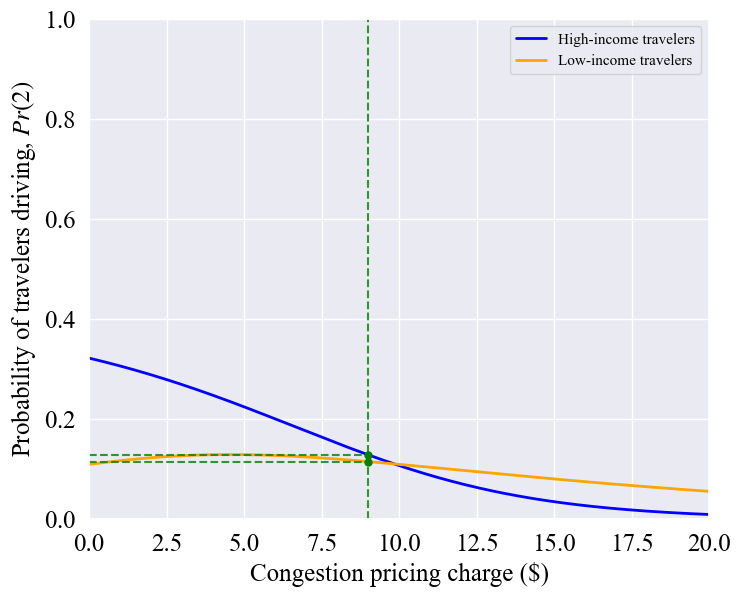

In [70]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_high_income_array, color = 'blue', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

plt.plot(toll_array, prob_car_low_income_array, color = 'orange', linewidth=2)

plt.legend(['High-income travelers', 'Low-income travelers'], loc = 'best')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
plt.axhline(y=np.array(prob_car_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5,alpha=0.8)
plt.axhline(y=np.array(prob_car_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, np.array(prob_car_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Probability of travelers driving, $Pr(2)$')
plt.show()

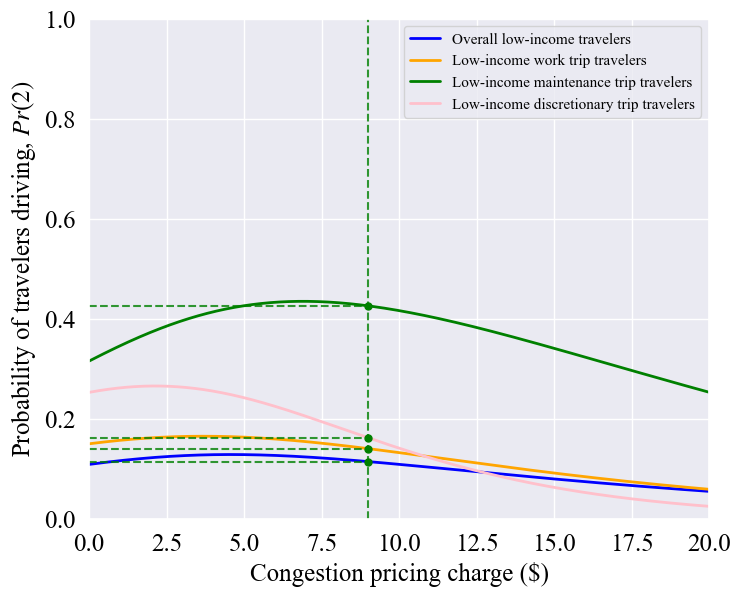

In [71]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_low_income_array, color = 'blue', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

plt.plot(toll_array, prob_car_work_low_income_array, color = 'orange', linewidth=2)
plt.plot(toll_array, prob_car_maintenance_low_income_array, color = 'green', linewidth=2)
plt.plot(toll_array, prob_car_discretionary_low_income_array, color = 'pink', linewidth=2)


plt.legend(['Overall low-income travelers', 'Low-income work trip travelers', 'Low-income maintenance trip travelers', 'Low-income discretionary trip travelers'], loc = 'best')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
plt.axhline(y=np.array(prob_car_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5,alpha=0.8)
plt.axhline(y=np.array(prob_car_work_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_maintenance_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_discretionary_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, np.array(prob_car_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_work_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_maintenance_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_discretionary_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Probability of travelers driving, $Pr(2)$')
plt.show()

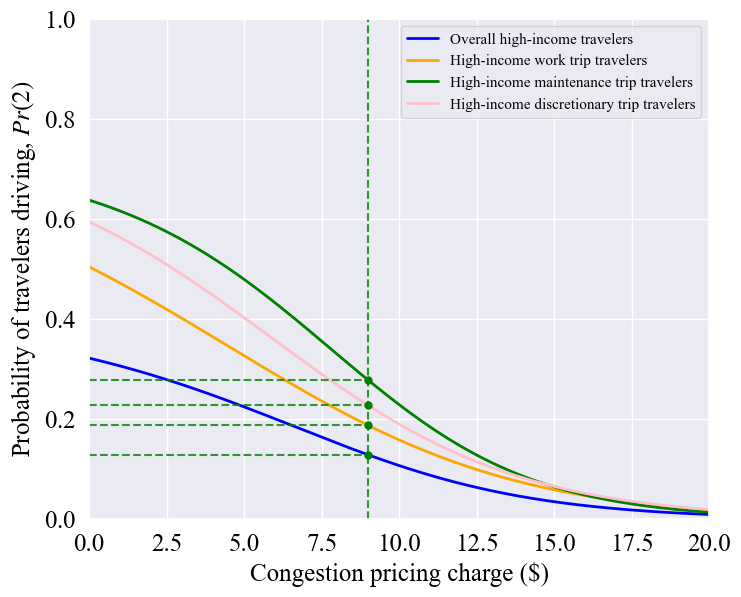

In [72]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_high_income_array, color = 'blue', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

plt.plot(toll_array, prob_car_work_high_income_array, color = 'orange', linewidth=2)
plt.plot(toll_array, prob_car_maintenance_high_income_array, color = 'green', linewidth=2)
plt.plot(toll_array, prob_car_discretionary_high_income_array, color = 'pink', linewidth=2)


plt.legend(['Overall high-income travelers', 'High-income work trip travelers', 'High-income maintenance trip travelers', 'High-income discretionary trip travelers'], loc = 'best')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
plt.axhline(y=np.array(prob_car_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5,alpha=0.8)
plt.axhline(y=np.array(prob_car_work_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_maintenance_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_discretionary_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, np.array(prob_car_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_work_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_maintenance_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_discretionary_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Probability of travelers driving, $Pr(2)$')
plt.show()

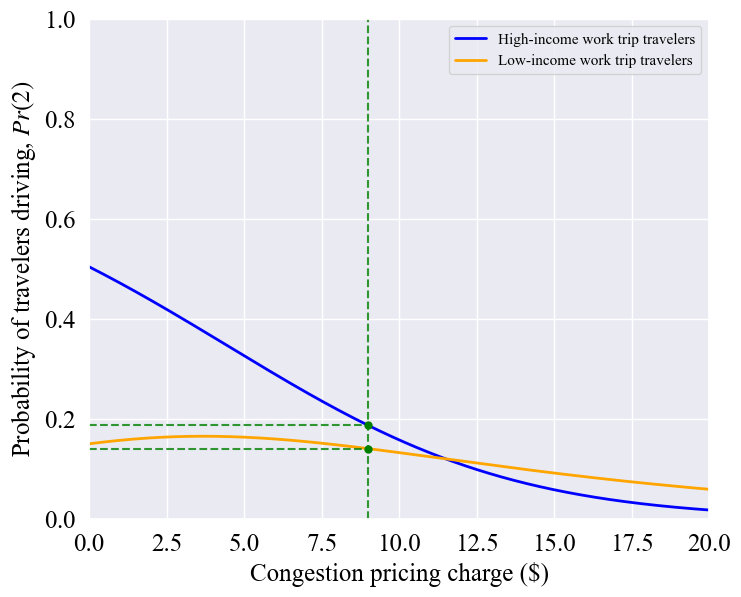

In [73]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_work_high_income_array, color = 'blue', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

plt.plot(toll_array, prob_car_work_low_income_array, color = 'orange', linewidth=2)


plt.legend(['High-income work trip travelers', 'Low-income work trip travelers'], loc = 'best')

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
plt.axhline(y=np.array(prob_car_work_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_work_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, np.array(prob_car_work_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_work_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('Congestion pricing charge (\$)')
plt.ylabel('Probability of travelers driving, $Pr(2)$')


plt.show()

## Income without Differentiating Trip Purposes

In [74]:
prop_high_income = len(df[df['highIncome']==1])/len(df)
print('The proportion of high-income travelers trips is', prop_high_income)
prop_low_income = len(df[df['highIncome']==0])/len(df)
print('The proportion of low-income travelers trips is', prop_low_income)

high_income = df[df['highIncome']==1]
low_income = df[df['highIncome']==0]

high_income_database = db.Database('CMS2019', high_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])
low_income_database = db.Database('CMS2019', low_income[['SUB_TT', 'SUB_CO', 'SUB_AV', 'CAR_TT', 'CAR_CO', 'CAR_AV', 'BUS_TT', 'BUS_CO', 'BUS_AV', 'FHV_TT', 'FHV_CO', 'FHV_AV', 'PURPOSE', 'CHOICE']])

The proportion of high-income travelers trips is 0.5539853677319985
The proportion of low-income travelers trips is 0.44601463226800153


In [75]:
# high-income travelers trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(high_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitHighIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting.
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# high-income travelers trips coefficients
beta_0_sub_high_income = 0 # ASC_SUB = 0

beta_1_high_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_high_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_high_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_high_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_high_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_high_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_high_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_high_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/1288091788.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitHighIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/1288091788.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitHighIncome
Nbr of parameters:		8
Sample size:			14387
Excluded data:			0
Null log likelihood:		-3383.742
Final log likelihood:		-3013.773
Likelihood ratio test (null):		739.9391
Rho square (null):			0.109
Rho bar square (null):			0.107
Akaike Information Criterion:	6043.546
Bayesian Information Criterion:	6104.138



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/1288091788.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.007173,0.001324,5.416288,6.084905e-08
1,B_COST_SUB,0.204867,0.020913,9.796264,0.000000e+00
2,ASC_CAR,1.865093,0.111704,16.696756,0.000000e+00
3,B_COST_CAR,-0.035507,0.006377,-5.567799,2.579771e-08
4,ASC_BUS,-0.193744,0.149836,-1.293043,1.959963e-01
5,B_COST_BUS,0.201697,0.031304,6.443254,1.169389e-10
6,ASC_FHV,0.497607,0.130814,3.803913,1.424283e-04
7,B_COST_FHV,0.003070,0.004151,0.739399,4.596650e-01


In [76]:
# low-income travelers trips
logprob = models.loglogit(V, av, CHOICE)

the_biogeme = bio.BIOGEME(low_income_database, logprob)
the_biogeme.modelName = 'CMS2019LogitLowIncome'
# the_biogeme.generate_html = False
the_biogeme.generate_pickle = False

# Calculate the null log likelihood for reporting.
the_biogeme.calculate_null_loglikelihood(av)

# Estimate the parameters
results = the_biogeme.estimate()

print(results.short_summary())

# Get the results in a pandas table
pandas_results = results.get_estimated_parameters()
display(pandas_results)

# low-income travelers trips coefficients
beta_0_sub_low_income = 0 # ASC_SUB = 0

beta_1_low_income = pandas_results.iat[0,1].item()  # B_TIME
beta_2_sub_low_income = pandas_results.iat[1,1].item()  # B_COST_SUB
beta_0_car_low_income = pandas_results.iat[2,1].item()  # ASC_CAR
beta_2_car_low_income = pandas_results.iat[3,1].item()  # B_COST_CAR

beta_0_bus_low_income = pandas_results.iat[4,1].item()  # ASC_BUS
beta_2_bus_low_income = pandas_results.iat[5,1].item()  # B_COST_BUS

beta_0_fhv_low_income = pandas_results.iat[6,1].item()  # ASC_FHV
beta_2_fhv_low_income = pandas_results.iat[7,1].item()  # B_COST_FHV

/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/417392771.py:5: DeprecationWarning: 'modelName' is deprecated. Please use 'model_name' instead.
  the_biogeme.modelName = 'CMS2019LogitLowIncome'
/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/417392771.py:7: DeprecationWarning: 'generate_pickle' is deprecated. Use 'generate_yaml' instead. This statement is ignored
  the_biogeme.generate_pickle = False


Results for model CMS2019LogitLowIncome
Nbr of parameters:		8
Sample size:			11583
Excluded data:			0
Null log likelihood:		-3193.525
Final log likelihood:		-1144.531
Likelihood ratio test (null):		4097.989
Rho square (null):			0.642
Rho bar square (null):			0.639
Akaike Information Criterion:	2305.062
Bayesian Information Criterion:	2363.92



/var/folders/qy/0t50b6dn5cjcq9lh7jqryw_r0000gn/T/ipykernel_31254/417392771.py:18: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  pandas_results = results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,B_TIME,0.300502,0.012342,24.347211,0.000000e+00
1,B_COST_SUB,0.196017,0.027046,7.247459,4.247713e-13
2,ASC_CAR,1.584859,0.167430,9.465796,0.000000e+00
3,B_COST_CAR,-0.050206,0.034200,-1.468031,1.420958e-01
4,ASC_BUS,0.138347,0.185418,0.746137,4.555844e-01
5,B_COST_BUS,0.195019,0.029242,6.669030,2.574985e-11
6,ASC_FHV,2.077975,0.225342,9.221415,0.000000e+00
7,B_COST_FHV,-0.096809,0.012247,-7.904940,2.664535e-15


In [77]:
def utilityWithoutPurpose(mode, toll, beta0, beta1, beta2):
    i = np.nan

    # CHOICE: subway: 1, car: 2, bus: 3, FHV: 4
    if mode == 'subway':
        i = 1
    elif mode == 'car':
        i = 2
    elif mode == 'bus':
        i = 3
    elif mode == 'fhv':
        i = 4
    
    return beta0 + beta1 * df[df['CHOICE'] == i]['durationCost'].mean() + beta2 * toll

In [78]:
toll = 0

# high-income trips
u_sub_high_income = utilityWithoutPurpose('subway', toll, beta_0_sub_high_income, beta_1_high_income, beta_2_sub_high_income)
print('The utility for high-income travelers subway trips under', toll, 'dollar toll is', u_sub_high_income)
u_car_high_income = utilityWithoutPurpose('car', toll, beta_0_car_high_income, beta_1_high_income, beta_2_car_high_income)
print('The utility for high-income travelers car trips under', toll, 'dollar toll is', u_car_high_income)
u_bus_high_income = utilityWithoutPurpose('bus', toll, beta_0_bus_high_income, beta_1_high_income, beta_2_bus_high_income)
print('The utility for high-income travelers bus trips under', toll, 'dollar toll is', u_bus_high_income)
u_fhv_high_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_high_income, beta_1_high_income, beta_2_fhv_high_income)
print('The utility for high-income travelers FHV trips under', toll, 'dollar toll is', u_fhv_high_income)

p1_high_income = logitmodelprob(u_sub_high_income, u_car_high_income, u_bus_high_income, u_fhv_high_income)
p2_high_income = logitmodelprob(u_car_high_income, u_sub_high_income, u_bus_high_income, u_fhv_high_income)
p3_high_income = logitmodelprob(u_bus_high_income, u_sub_high_income, u_car_high_income, u_fhv_high_income)
p4_high_income = logitmodelprob(u_fhv_high_income, u_sub_high_income, u_car_high_income, u_bus_high_income)

print('The probability of high-income travelers taking subway under', toll, 'dollar toll is', p1_high_income)
print('The probability of high-income travelers driving under', toll, 'dollar toll is', p2_high_income)
print('The probability of high-income travelers taking bus under', toll, 'dollar toll is', p3_high_income)
print('The probability of high-income travelers using FHV under', toll, 'dollar toll is', p4_high_income)
print()

# low-income trips
u_sub_low_income = utilityWithoutPurpose('subway', toll, beta_0_sub_low_income, beta_1_low_income, beta_2_sub_low_income)
print('The utility for low-income travelers subway trips under', toll, 'dollar toll is', u_sub_low_income)
u_car_low_income = utilityWithoutPurpose('car', toll, beta_0_car_low_income, beta_1_low_income, beta_2_car_low_income)
print('The utility for low-income travelers car trips under', toll, 'dollar toll is', u_car_low_income)
u_bus_low_income = utilityWithoutPurpose('bus', toll, beta_0_bus_low_income, beta_1_low_income, beta_2_bus_low_income)
print('The utility for low-income travelers bus trips under', toll, 'dollar toll is', u_bus_low_income)
u_fhv_low_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_low_income, beta_1_low_income, beta_2_fhv_low_income)
print('The utility for low-income travelers FHV trips under', toll, 'dollar toll is', u_fhv_low_income)

p1_low_income = logitmodelprob(u_sub_low_income, u_car_low_income, u_bus_low_income, u_fhv_low_income)
p2_low_income = logitmodelprob(u_car_low_income, u_sub_low_income, u_bus_low_income, u_fhv_low_income)
p3_low_income = logitmodelprob(u_bus_low_income, u_sub_low_income, u_car_low_income, u_fhv_low_income)
p4_low_income = logitmodelprob(u_fhv_low_income, u_sub_low_income, u_car_low_income, u_bus_low_income)

print('The probability of low-income travelers taking subway under', toll, 'dollar toll is', p1_low_income)
print('The probability of low-income travelers driving under', toll, 'dollar toll is', p2_low_income)
print('The probability of low-income travelers taking bus under', toll, 'dollar toll is', p3_low_income)
print('The probability of low-income travelers using FHV under', toll, 'dollar toll is', p4_low_income)
print()


# overall probability for two income groups
p1 = prop_high_income * p1_high_income + prop_low_income * p1_low_income
p2 = prop_high_income * p2_high_income + prop_low_income * p2_low_income
p3 = prop_high_income * p3_high_income + prop_low_income * p3_low_income
p4 = prop_high_income * p4_high_income + prop_low_income * p4_low_income
print()
print('The overall probability of travelers taking subway under', toll, 'dollar toll is', p1)
print('The overall probability of travelers driving under', toll, 'dollar toll is', p2)
print('The overall probability of travelers taking bus under', toll, 'dollar toll is', p3)
print('The overall probability of travelers using FHV under', toll, 'dollar toll is', p4)

The utility for high-income travelers subway trips under 0 dollar toll is 0.1103651761203018
The utility for high-income travelers car trips under 0 dollar toll is 1.9438517862337934
The utility for high-income travelers bus trips under 0 dollar toll is -0.11860035103265011
The utility for high-income travelers FHV trips under 0 dollar toll is 0.5777486203530875
The probability of high-income travelers taking subway under 0 dollar toll is 0.10366100753189719
The probability of high-income travelers driving under 0 dollar toll is 0.6484679899568825
The probability of high-income travelers taking bus under 0 dollar toll is 0.0824473992495994
The probability of high-income travelers using FHV under 0 dollar toll is 0.165423603261621

The utility for low-income travelers subway trips under 0 dollar toll is 4.623693322765248
The utility for low-income travelers car trips under 0 dollar toll is 4.88441502208249
The utility for low-income travelers bus trips under 0 dollar toll is 3.286459317

In [79]:
toll = 9

# high-income trips
u_sub_high_income = utilityWithoutPurpose('subway', toll, beta_0_sub_high_income, beta_1_high_income, beta_2_sub_high_income)
print('The utility for high-income travelers subway trips under', toll, 'dollar toll is', u_sub_high_income)
u_car_high_income = utilityWithoutPurpose('car', toll, beta_0_car_high_income, beta_1_high_income, beta_2_car_high_income)
print('The utility for high-income travelers car trips under', toll, 'dollar toll is', u_car_high_income)
u_bus_high_income = utilityWithoutPurpose('bus', toll, beta_0_bus_high_income, beta_1_high_income, beta_2_bus_high_income)
print('The utility for high-income travelers bus trips under', toll, 'dollar toll is', u_bus_high_income)
u_fhv_high_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_high_income, beta_1_high_income, beta_2_fhv_high_income)
print('The utility for high-income travelers FHV trips under', toll, 'dollar toll is', u_fhv_high_income)

p1_high_income = logitmodelprob(u_sub_high_income, u_car_high_income, u_bus_high_income, u_fhv_high_income)
p2_high_income = logitmodelprob(u_car_high_income, u_sub_high_income, u_bus_high_income, u_fhv_high_income)
p3_high_income = logitmodelprob(u_bus_high_income, u_sub_high_income, u_car_high_income, u_fhv_high_income)
p4_high_income = logitmodelprob(u_fhv_high_income, u_sub_high_income, u_car_high_income, u_bus_high_income)

print('The probability of high-income travelers taking subway under', toll, 'dollar toll is', p1_high_income)
print('The probability of high-income travelers driving under', toll, 'dollar toll is', p2_high_income)
print('The probability of high-income travelers taking bus under', toll, 'dollar toll is', p3_high_income)
print('The probability of high-income travelers using FHV under', toll, 'dollar toll is', p4_high_income)
print()

# low-income trips
u_sub_low_income = utilityWithoutPurpose('subway', toll, beta_0_sub_low_income, beta_1_low_income, beta_2_sub_low_income)
print('The utility for low-income travelers subway trips under', toll, 'dollar toll is', u_sub_low_income)
u_car_low_income = utilityWithoutPurpose('car', toll, beta_0_car_low_income, beta_1_low_income, beta_2_car_low_income)
print('The utility for low-income travelers car trips under', toll, 'dollar toll is', u_car_low_income)
u_bus_low_income = utilityWithoutPurpose('bus', toll, beta_0_bus_low_income, beta_1_low_income, beta_2_bus_low_income)
print('The utility for low-income travelers bus trips under', toll, 'dollar toll is', u_bus_low_income)
u_fhv_low_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_low_income, beta_1_low_income, beta_2_fhv_low_income)
print('The utility for low-income travelers FHV trips under', toll, 'dollar toll is', u_fhv_low_income)

p1_low_income = logitmodelprob(u_sub_low_income, u_car_low_income, u_bus_low_income, u_fhv_low_income)
p2_low_income = logitmodelprob(u_car_low_income, u_sub_low_income, u_bus_low_income, u_fhv_low_income)
p3_low_income = logitmodelprob(u_bus_low_income, u_sub_low_income, u_car_low_income, u_fhv_low_income)
p4_low_income = logitmodelprob(u_fhv_low_income, u_sub_low_income, u_car_low_income, u_bus_low_income)

print('The probability of low-income travelers taking subway under', toll, 'dollar toll is', p1_low_income)
print('The probability of low-income travelers driving under', toll, 'dollar toll is', p2_low_income)
print('The probability of low-income travelers taking bus under', toll, 'dollar toll is', p3_low_income)
print('The probability of low-income travelers using FHV under', toll, 'dollar toll is', p4_low_income)
print()


# overall probability for two income groups
p1 = prop_high_income * p1_high_income + prop_low_income * p1_low_income
p2 = prop_high_income * p2_high_income + prop_low_income * p2_low_income
p3 = prop_high_income * p3_high_income + prop_low_income * p3_low_income
p4 = prop_high_income * p4_high_income + prop_low_income * p4_low_income
print()
print('The overall probability of travelers taking subway under', toll, 'dollar toll is', p1)
print('The overall probability of travelers driving under', toll, 'dollar toll is', p2)
print('The overall probability of travelers taking bus under', toll, 'dollar toll is', p3)
print('The overall probability of travelers using FHV under', toll, 'dollar toll is', p4)

The utility for high-income travelers subway trips under 9 dollar toll is 1.9541662366710724
The utility for high-income travelers car trips under 9 dollar toll is 1.6242906654141576
The utility for high-income travelers bus trips under 9 dollar toll is 1.696670591389965
The utility for high-income travelers FHV trips under 9 dollar toll is 0.6053748303462768
The probability of high-income travelers taking subway under 9 dollar toll is 0.36343126253680313
The probability of high-income travelers driving under 9 dollar toll is 0.26131187279392376
The probability of high-income travelers taking bus under 9 dollar toll is 0.2809269117239268
The probability of high-income travelers using FHV under 9 dollar toll is 0.09432995294534635

The utility for low-income travelers subway trips under 9 dollar toll is 6.387846202885908
The utility for low-income travelers car trips under 9 dollar toll is 4.432561105498165
The utility for low-income travelers bus trips under 9 dollar toll is 5.04162798

In [80]:
print('The overall change in passenger vehicle traffic volume under $9 congestion pricing is:', (0.19-0.48)*100, '%')
print('The change in passenger vehicle traffic volume for high-income travelers under $9 congestion pricing is:', (0.26-0.65)*100, '%')
print('The change in passenger vehicle traffic volume for low-income travelers under $9 congestion pricing is:', (0.09-0.27)*100, '%')


The overall change in passenger vehicle traffic volume under $9 congestion pricing is: -28.999999999999996 %
The change in passenger vehicle traffic volume for high-income travelers under $9 congestion pricing is: -39.0 %
The change in passenger vehicle traffic volume for low-income travelers under $9 congestion pricing is: -18.000000000000004 %


### Visualization

In [81]:
toll_array = np.arange(0, 20, 0.01)
toll_array

# high-income trips
prob_subway_high_income_array = []
prob_car_high_income_array = []
prob_bus_high_income_array = []
prob_fhv_high_income_array = []
for toll in toll_array:
    u_sub_high_income = utilityWithoutPurpose('subway', toll, beta_0_sub_high_income, beta_1_high_income, beta_2_sub_high_income)
    u_car_high_income = utilityWithoutPurpose('car', toll, beta_0_car_high_income, beta_1_high_income, beta_2_car_high_income)
    u_bus_high_income = utilityWithoutPurpose('bus', toll, beta_0_bus_high_income, beta_1_high_income, beta_2_bus_high_income)
    u_fhv_high_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_high_income, beta_1_high_income, beta_2_fhv_high_income)

    p1_high_income = logitmodelprob(u_sub_high_income, u_car_high_income, u_bus_high_income, u_fhv_high_income)
    p2_high_income = logitmodelprob(u_car_high_income, u_sub_high_income, u_bus_high_income, u_fhv_high_income)
    p3_high_income = logitmodelprob(u_bus_high_income, u_sub_high_income, u_car_high_income, u_fhv_high_income)
    p4_high_income = logitmodelprob(u_fhv_high_income, u_sub_high_income, u_car_high_income, u_bus_high_income)

    prob_subway_high_income_array.append(p1_high_income) 
    prob_car_high_income_array.append(p2_high_income)
    prob_bus_high_income_array.append(p3_high_income)
    prob_fhv_high_income_array.append(p4_high_income)

# low-income trips
prob_subway_low_income_array = []
prob_car_low_income_array = []
prob_bus_low_income_array = []
prob_fhv_low_income_array = []
for toll in toll_array:
    u_sub_low_income = utilityWithoutPurpose('subway', toll, beta_0_sub_low_income, beta_1_low_income, beta_2_sub_low_income)
    u_car_low_income = utilityWithoutPurpose('car', toll, beta_0_car_low_income, beta_1_low_income, beta_2_car_low_income)
    u_bus_low_income = utilityWithoutPurpose('bus', toll, beta_0_bus_low_income, beta_1_low_income, beta_2_bus_low_income)
    u_fhv_low_income = utilityWithoutPurpose('fhv', toll, beta_0_fhv_low_income, beta_1_low_income, beta_2_fhv_low_income)

    p1_low_income = logitmodelprob(u_sub_low_income, u_car_low_income, u_bus_low_income, u_fhv_low_income)
    p2_low_income = logitmodelprob(u_car_low_income, u_sub_low_income, u_bus_low_income, u_fhv_low_income)
    p3_low_income = logitmodelprob(u_bus_low_income, u_sub_low_income, u_car_low_income, u_fhv_low_income)
    p4_low_income = logitmodelprob(u_fhv_low_income, u_sub_low_income, u_car_low_income, u_bus_low_income)

    prob_subway_low_income_array.append(p1_low_income) 
    prob_car_low_income_array.append(p2_low_income)
    prob_bus_low_income_array.append(p3_low_income)
    prob_fhv_low_income_array.append(p4_low_income)


# # find where prob_car_array is closest to 0.62 (0.79-0.17)
# index_62 = (np.abs(prob_car_array - 0.62)).argmin()
# toll_62 = toll_array[index_62]
# print('The congestion pricing charge that makes the probability of driving equal to 0.62 is', toll_62)

# # find where prob_car_work_array is closest to 0.51 (0.68-0.17)
# index_51_work = (np.abs(np.array(prob_car_work_array) - 0.51)).argmin()
# toll_51_work = toll_array[index_51_work]
# print('The congestion pricing charge that makes the probability of driving equal to 0.51 for work trips is', toll_51_work)

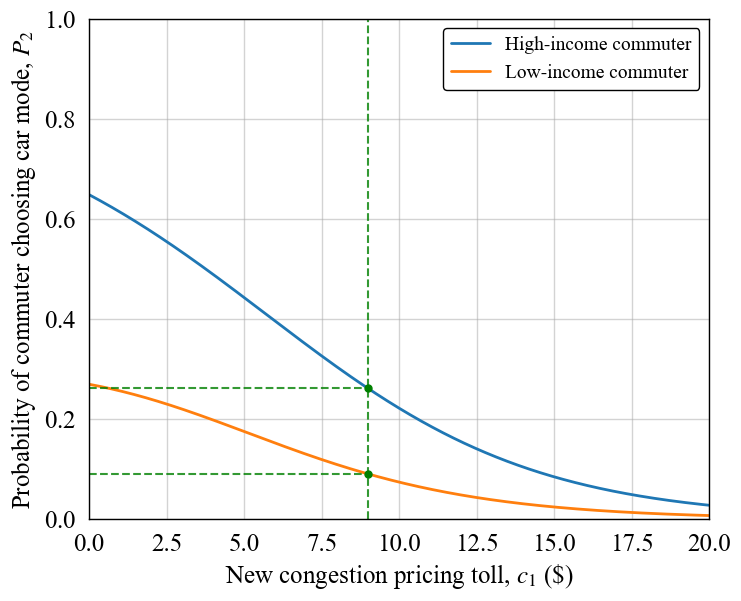

In [82]:
fig, ax = plt.subplots()
plt.plot(toll_array, prob_car_high_income_array, color = 'tab:blue', linewidth=2)
plt.ylim(0, 1)
plt.xlim(0, 20)

plt.plot(toll_array, prob_car_low_income_array, color = 'tab:orange', linewidth=2)


leg = plt.legend(['High-income commuter', 'Low-income commuter'], loc = 'best', edgecolor='black', framealpha=1, fontsize = 14)
leg.get_frame().set_facecolor('white') # Remove the background

# plot a vertical line at x=9
plt.axvline(x=9, color='green', linestyle='--', alpha=0.8, label='Congestion pricing toll of $9')

# plot a vertical line for each lines intercepting with x = 9 starting from x = 0 to x = 9
plt.axhline(y=np.array(prob_car_high_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=np.array(prob_car_low_income_array)[np.where(toll_array == 9)], xmin=0, xmax=9/20, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# plot a dot at the intersection of each horizontal line and the vertical line
plt.plot(9, np.array(prob_car_high_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)
plt.plot(9, np.array(prob_car_low_income_array)[np.where(toll_array == 9)], marker='o', color='green', markersize=5)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.xlabel('New congestion pricing toll, $c_{1}$ (\$)')
plt.ylabel('Probability of commuter choosing car mode, $P_{2}$')

ax.set_facecolor('white') 
ax.grid(True, color='#A9A9A9', alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

plt.savefig('probCarIncome.pdf', dpi=1200, bbox_inches='tight')

plt.show()